# Laboratorio 1 — Series de Tiempo (versión corregida)
### Data Science | Universidad del Valle de Guatemala
**Sección 10 | Ing. Lynette García**

**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Lab1-DS.git

Dataset: ingreso mensual de viajeros internacionales a Guatemala (2009-2026).

Categorías libres seleccionadas: Vías de ingreso (Aérea, Terrestre, Marítima) y Regiones geográficas (Región dos: Top 3 por acumulado — América del Centro, América del Norte, Europa).

In [1]:
import warnings, os, logging
warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
import scipy.stats as stats

FIGS = "figs"
os.makedirs(FIGS, exist_ok=True)
plt.rcParams["figure.dpi"] = 100

Importing plotly failed. Interactive plots will not work.


## Carga de datos

In [2]:
df = pd.read_excel("Base_Migracion_2009-2026jun.xlsx")
print("Dimensiones:", df.shape)
df.dtypes

Dimensiones: (161036, 13)


Año                        int64
Mes cod                    int64
Mes                          str
Vía                          str
Frontera                     str
País                         str
Región                       str
Región dos                   str
Regiones OMT                 str
MCEO                         str
Agrupación Residencia        str
Tipo de Viajero              str
Viajero                  float64
dtype: object

## Limpieza y calidad de datos\n\nRevisamos nulos, duplicados, consistencia de categorías y valores atípicos.

In [3]:
print("--- Nulos por columna ---")
print(df.isna().sum())
print("\n--- Duplicados exactos ---", df.duplicated().sum())
print("\n--- Valores unicos de 'Región dos' ---")
print(df["Región dos"].value_counts())

--- Nulos por columna ---
Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
dtype: int64



--- Duplicados exactos --- 0

--- Valores unicos de 'Región dos' ---
Región dos
Europa                         54640
América Del Centro             31362
América Del Sur y el Caribe    24734
América Del Norte              17306
Asia                           13247
Otros Paises Del Mundo          8979
Oceanía                         5746
Oriente Medio                   4805
Cruceristas                      196
0                                 13
Cruceros                           8
Name: count, dtype: int64


In [4]:
# Corregimos inconsistencias de nomenclatura en Región dos
df["Región dos"] = df["Región dos"].replace({"Cruceros": "Cruceristas", "0": "Sin Clasificar"})

print("Registros con Viajero < 0:", (df["Viajero"] < 0).sum())
print("Registros con Viajero == 0:", (df["Viajero"] == 0).sum())
print("Registros con parte decimal no entera:", (df["Viajero"] % 1 != 0).sum())

Registros con Viajero < 0: 0
Registros con Viajero == 0: 54
Registros con parte decimal no entera: 51272


In [5]:
q1, q3 = df["Viajero"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_sup = q3 + 3 * iqr
outliers = df[df["Viajero"] > lim_sup]
print(f"Registros por encima de Q3+3*IQR ({lim_sup:.1f}): {len(outliers)} de {len(df)}")
outliers.groupby("Tipo de Viajero")["Viajero"].agg(["count", "mean", "max"])

Registros por encima de Q3+3*IQR (149.6): 21104 de 161036


,count,mean,max
Tipo de Viajero,,,
Cruceristas,203,5439.985222,21680.933573
Excursionista,3991,2201.153453,38463.026064
Turista,13915,2582.886672,83511.000000
Viajero,2995,1366.694064,92336.035067


No hay valores negativos. Los valores decimales en `Viajero` (~32% de los registros) son consistentes con cifras oficiales agregadas/estimadas del INGUAT y no representan un error de captura. Con el criterio IQR (Q3+3·IQR) se detecta ~13% de registros como atípicos a nivel de fila individual, concentrados en Turista — esperado, dado que el dataset combina miles de combinaciones de país/vía/frontera con volúmenes muy distintos entre sí; los atípicos relevantes para series de tiempo se evalúan más adelante con la descomposición y los residuos de cada modelo.

## Análisis Exploratorio de Datos

### a. Comportamiento temporal del número de viajeros (vista preliminar total)

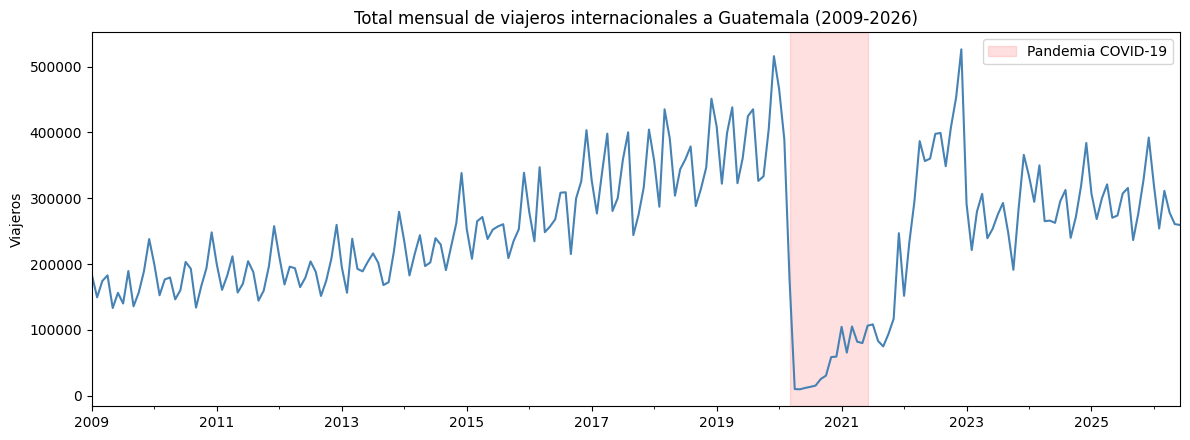

Promedio mensual pre-pandemia (2015-2019): 323458
Mínimo durante pandemia (2020): 9779
Promedio mensual post-pandemia (2023-2026): 288630


In [6]:
mensual_prev = df.groupby(["Año","Mes cod"])["Viajero"].sum().reset_index()
fechas_prev = pd.to_datetime(dict(year=mensual_prev["Año"], month=mensual_prev["Mes cod"], day=1))
ts_prev = pd.Series(mensual_prev["Viajero"].values, index=pd.DatetimeIndex(fechas_prev)).sort_index()

fig, ax = plt.subplots(figsize=(12,4.5))
ts_prev.plot(ax=ax, color="steelblue")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"), color="red", alpha=0.12, label="Pandemia COVID-19")
ax.set_title("Total mensual de viajeros internacionales a Guatemala (2009-2026)")
ax.set_ylabel("Viajeros"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/total_preliminar.png", dpi=150, bbox_inches="tight"); plt.show()

print("Promedio mensual pre-pandemia (2015-2019):", round(ts_prev["2015":"2019"].mean()))
print("Mínimo durante pandemia (2020):", round(ts_prev["2020"].min()))
print("Promedio mensual post-pandemia (2023-2026):", round(ts_prev["2023":"2026"].mean()))

Se observa una tendencia creciente de largo plazo con un patrón estacional anual claro (picos en temporada alta: Semana Santa, julio-agosto y diciembre). El choque de la pandemia (marzo 2020 - mediados 2021) provoca un colapso casi total del ingreso de viajeros, seguido de una recuperación fuerte que hacia 2023-2026 supera los niveles pre-pandemia.

### b. Países con mayor cantidad de viajeros

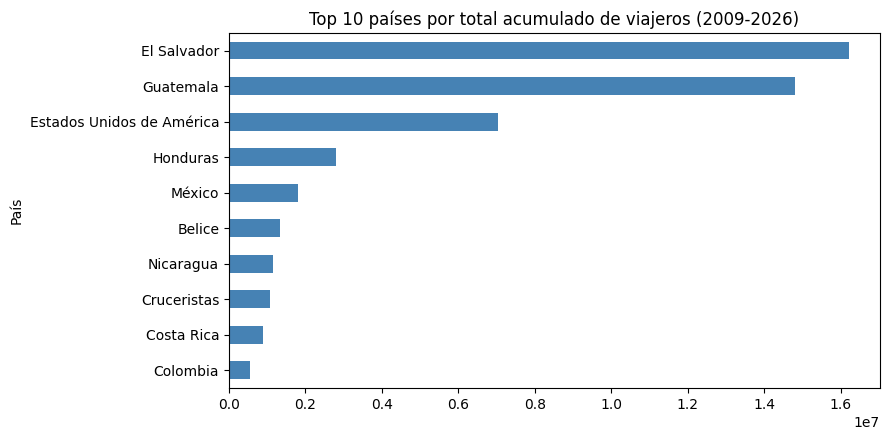

País
El Salvador                  1.621398e+07
Guatemala                    1.479233e+07
Estados Unidos de América    7.047843e+06
Honduras                     2.788233e+06
México                       1.808946e+06
Belice                       1.328256e+06
Nicaragua                    1.164343e+06
Cruceristas                  1.078372e+06
Costa Rica                   8.821797e+05
Colombia                     5.610353e+05
Name: Viajero, dtype: float64

In [7]:
top_paises = df.groupby("País")["Viajero"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,4.5))
top_paises.head(10).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 10 países por total acumulado de viajeros (2009-2026)")
plt.tight_layout(); plt.savefig(f"{FIGS}/top_paises.png", dpi=150, bbox_inches="tight"); plt.show()
top_paises.head(10)

Los tres mercados con mayor acumulado histórico son **El Salvador**, **Guatemala** (viajeros con residencia declarada en el propio país, típicamente en fronteras terrestres) y **Estados Unidos**, seguidos por Honduras y México — confirmando el peso dominante del tránsito centroamericano fronterizo.

### c. Regiones con mayor cantidad de viajeros

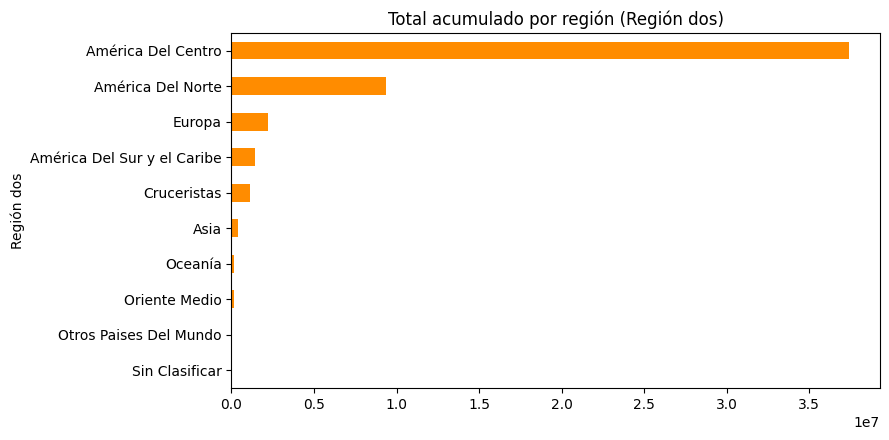

Región dos
América Del Centro             3.740653e+07
América Del Norte              9.383035e+06
Europa                         2.222621e+06
América Del Sur y el Caribe    1.447950e+06
Cruceristas                    1.104402e+06
Asia                           4.217025e+05
Oceanía                        1.400472e+05
Oriente Medio                  1.357125e+05
Otros Paises Del Mundo         2.511115e+04
Sin Clasificar                 8.210000e+02
Name: Viajero, dtype: float64

In [8]:
top_regiones = df.groupby("Región dos")["Viajero"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,4.5))
top_regiones.sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Total acumulado por región (Región dos)")
plt.tight_layout(); plt.savefig(f"{FIGS}/top_regiones.png", dpi=150, bbox_inches="tight"); plt.show()
top_regiones

**América del Centro** domina de forma abrumadora el acumulado histórico, seguida —a mucha distancia— por **América del Norte** y **Europa**. Estas son las tres regiones seleccionadas para construir series de tiempo individuales.

### d. Vías de ingreso y fronteras más utilizadas

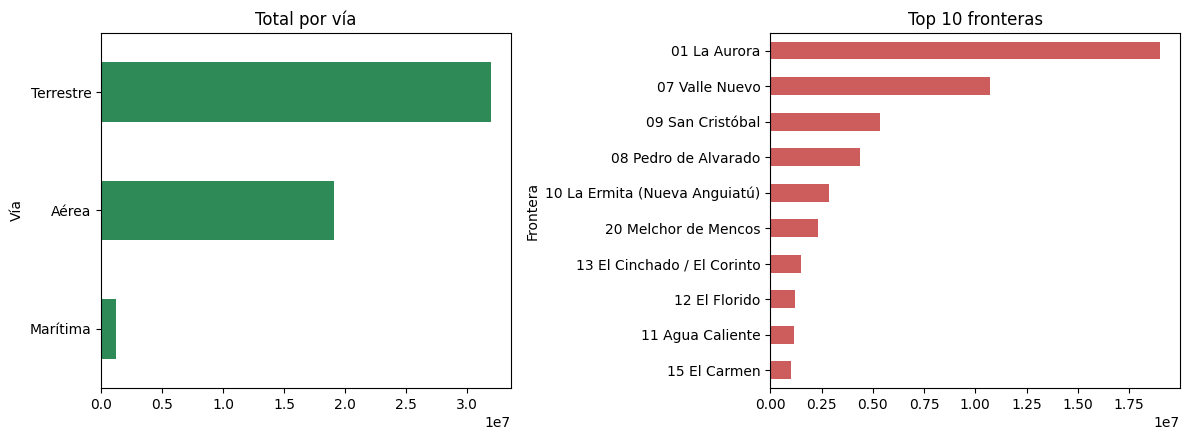

--- Vía ---
Vía
Terrestre    3.199530e+07
Aérea        1.906385e+07
Marítima     1.228782e+06
Name: Viajero, dtype: float64

--- Top 10 fronteras ---
Frontera
01 La Aurora                     1.903440e+07
07 Valle Nuevo                   1.073234e+07
09 San Cristóbal                 5.363009e+06
08 Pedro de Alvarado             4.393577e+06
10 La Ermita (Nueva Anguiatú)    2.879210e+06
20 Melchor de Mencos             2.349551e+06
13 El Cinchado / El Corinto      1.497006e+06
12 El Florido                    1.221040e+06
11 Agua Caliente                 1.154542e+06
15 El Carmen                     1.023092e+06
Name: Viajero, dtype: float64


In [9]:
via_tot = df.groupby("Vía")["Viajero"].sum().sort_values(ascending=False)
frontera_tot = df.groupby("Frontera")["Viajero"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1,2, figsize=(12,4.5))
via_tot.sort_values().plot(kind="barh", ax=axes[0], color="seagreen"); axes[0].set_title("Total por vía")
frontera_tot.head(10).sort_values().plot(kind="barh", ax=axes[1], color="indianred"); axes[1].set_title("Top 10 fronteras")
plt.tight_layout(); plt.savefig(f"{FIGS}/vias_fronteras.png", dpi=150, bbox_inches="tight"); plt.show()

print("--- Vía ---"); print(via_tot)
print("\n--- Top 10 fronteras ---"); print(frontera_tot.head(10))

La vía **Terrestre** concentra la mayor cantidad de viajeros acumulados, por encima de **Aérea** y muy por encima de **Marítima**. En fronteras, **01 La Aurora** (aeropuerto) es la más importante, seguida de los pasos terrestres **07 Valle Nuevo** y **09 San Cristóbal**.

### e-f. Valores faltantes, duplicados, atípicos y estadísticas descriptivas

--- Estadísticas descriptivas de Viajero (nivel registro) ---
count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

--- Total de viajeros por Tipo de Viajero ---
Tipo de Viajero
Turista          3.764273e+07
Excursionista    9.069184e+06
Viajero          4.471622e+06
Cruceristas      1.104402e+06
Name: Viajero, dtype: float64


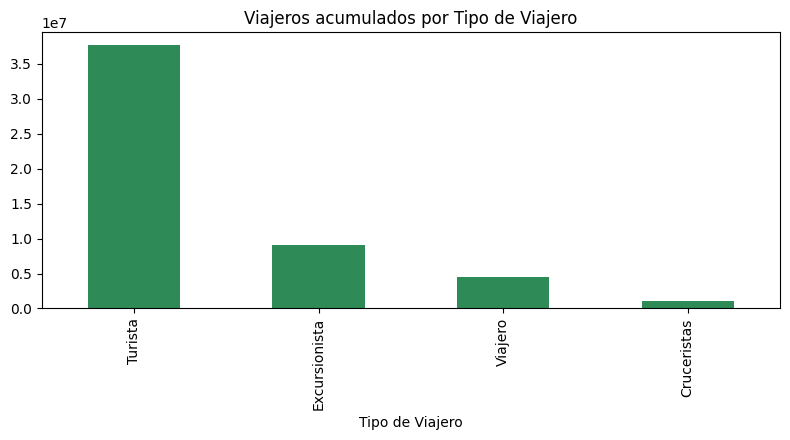

In [10]:
print("--- Estadísticas descriptivas de Viajero (nivel registro) ---")
print(df["Viajero"].describe())
print("\n--- Total de viajeros por Tipo de Viajero ---")
tipo_tot = df.groupby("Tipo de Viajero")["Viajero"].sum().sort_values(ascending=False)
print(tipo_tot)

fig, ax = plt.subplots(figsize=(8,4.5))
tipo_tot.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Viajeros acumulados por Tipo de Viajero")
plt.tight_layout(); plt.savefig(f"{FIGS}/tipo_viajero.png", dpi=150, bbox_inches="tight"); plt.show()

No existen valores nulos ni duplicados exactos. Los atípicos a nivel de fila (criterio IQR) corresponden a combinaciones de alto volumen perfectamente válidas en el contexto de negocio, no errores de captura. Por tipo de viajero, **Turista** domina el acumulado, seguido de Excursionista, **Viajero** (categoría con discontinuidad metodológica 2022-2023, ver nota de revisión) y Cruceristas.

## División Entrenamiento / Prueba

Corte cronológico ~70/30 sobre los 210 meses (nunca un split aleatorio, rompería la dependencia temporal): entrenamiento = enero 2009 a marzo 2021 (147 meses, 70%), prueba = abril 2021 a junio 2026 (63 meses, 30%). El mismo punto de corte se usa en las 7 series para que los resultados sean comparables.

In [11]:
SPLIT_DATE = pd.Timestamp("2021-04-01")

mensual_split = df.groupby(["Año","Mes cod"])["Viajero"].sum().reset_index()
fechas_split = pd.to_datetime(dict(year=mensual_split["Año"], month=mensual_split["Mes cod"], day=1))
ts_check = pd.Series(mensual_split["Viajero"].values, index=pd.DatetimeIndex(fechas_split)).sort_index()

train_n = (ts_check.index < SPLIT_DATE).sum()
test_n = (ts_check.index >= SPLIT_DATE).sum()
print(f"Total de meses: {len(ts_check)}")
print(f"Entrenamiento: {ts_check.index[0]:%Y-%m} a {ts_check[ts_check.index < SPLIT_DATE].index[-1]:%Y-%m} ({train_n} meses, {train_n/len(ts_check)*100:.1f}%)")
print(f"Prueba:        {ts_check[ts_check.index >= SPLIT_DATE].index[0]:%Y-%m} a {ts_check.index[-1]:%Y-%m} ({test_n} meses, {test_n/len(ts_check)*100:.1f}%)")

Total de meses: 210
Entrenamiento: 2009-01 a 2021-03 (147 meses, 70.0%)
Prueba:        2021-04 a 2026-06 (63 meses, 30.0%)


## Construcción de Series de Tiempo Mensuales

Se construye la serie obligatoria (Total) y, para las dos categorías libres — Vías de ingreso y Regiones geográficas —, una serie por cada valor (1 + 3 + 3 = 7 series).

**Corrección de metodología:** para las 6 series adicionales y la serie Total se excluyen los registros con `Tipo de Viajero = "Viajero"`, por la discontinuidad metodológica 2022-2023 documentada en el enunciado. Se conservan Turista, Excursionista y Cruceristas.

**Excepción — Vía Marítima:** a partir de 2023 el 100% de sus registros se reclasifican bajo el tipo "Viajero"; aplicar el mismo filtro truncaría la serie en diciembre 2022. Por eso, únicamente para esta serie, se usa el total de Viajero sin excluir ningún tipo — sus valores desde 2023 deben interpretarse con esta salvedad.

In [12]:
df_series = df[df["Tipo de Viajero"] != "Viajero"].copy()

def build_monthly(mask_df):
    mensual = mask_df.groupby(["Año","Mes cod"])["Viajero"].sum().reset_index()
    fechas = pd.to_datetime(dict(year=mensual["Año"], month=mensual["Mes cod"], day=1))
    s = pd.Series(mensual["Viajero"].values, index=pd.DatetimeIndex(fechas))
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
    s = s.reindex(full_idx, fill_value=0)
    s.index.freq = "MS"
    return s

ts_total     = build_monthly(df_series)
ts_aerea     = build_monthly(df_series[df_series["Vía"] == "Aérea"])
ts_terrestre = build_monthly(df_series[df_series["Vía"] == "Terrestre"])
ts_maritima  = build_monthly(df[df["Vía"] == "Marítima"])  # excepción: sin filtro de tipo
ts_centro    = build_monthly(df_series[df_series["Región dos"] == "América Del Centro"])
ts_norte     = build_monthly(df_series[df_series["Región dos"] == "América Del Norte"])
ts_europa    = build_monthly(df_series[df_series["Región dos"] == "Europa"])

series_dict = {
    "total": (ts_total, "Total mensual", "steelblue"),
    "aerea": (ts_aerea, "Vía Aérea", "darkcyan"),
    "terrestre": (ts_terrestre, "Vía Terrestre", "sienna"),
    "maritima": (ts_maritima, "Vía Marítima", "teal"),
    "centro": (ts_centro, "América del Centro", "darkorange"),
    "norte": (ts_norte, "América del Norte", "purple"),
    "europa": (ts_europa, "Europa", "green"),
}

for slug, (ts, titulo, _) in series_dict.items():
    print(f"{titulo:20s} inicio={ts.index[0]:%Y-%m} fin={ts.index[-1]:%Y-%m} n={len(ts)} freq={ts.index.freqstr} ceros={(ts==0).sum()}")

Total mensual        inicio=2009-01 fin=2026-06 n=210 freq=MS ceros=0
Vía Aérea            inicio=2009-01 fin=2026-06 n=210 freq=MS ceros=0
Vía Terrestre        inicio=2009-01 fin=2026-06 n=210 freq=MS ceros=0
Vía Marítima         inicio=2009-01 fin=2026-06 n=210 freq=MS ceros=27
América del Centro   inicio=2009-01 fin=2026-06 n=210 freq=MS ceros=0
América del Norte    inicio=2009-01 fin=2026-06 n=210 freq=MS ceros=5
Europa               inicio=2009-01 fin=2026-06 n=210 freq=MS ceros=5


## Análisis de cada serie (a-k)

Se define una función reutilizable que aplica el mismo procedimiento (gráfico, descomposición sobre el entrenamiento, transformación, ACF/ADF con posible diferenciación estacional, selección y comparación de modelos ARIMA, comparación con Holt-Winters / Suavizamiento Exponencial Simple / Seasonal Naive / Prophet, y predicción sobre el conjunto de prueba) a cada una de las 7 series.

In [13]:
def analyze_series(ts, slug, titulo, color="steelblue"):
    """Aplica los incisos a-k del punto 4: grafico, descomposicion, transformacion,
    ACF/ADF con posible diferenciacion estacional, comparacion de modelos ARIMA,
    comparacion con Holt-Winters / Suavizamiento Exp. Simple / Seasonal Naive / Prophet,
    y prediccion sobre el conjunto de prueba."""
    res = {"slug": slug, "titulo": titulo}
    res["inicio"] = ts.index[0]; res["fin"] = ts.index[-1]; res["n"] = len(ts)
    train_full = ts[ts.index < SPLIT_DATE]

    fig, ax = plt.subplots(figsize=(12,4))
    ts.plot(ax=ax, color=color)
    ax.axvline(SPLIT_DATE, color="gray", linestyle=":")
    ax.set_title(f"Viajeros -- {titulo} (serie mensual)")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad de viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    plt.tight_layout(); plt.savefig(f"{FIGS}/serie_{slug}.png", dpi=150, bbox_inches="tight"); plt.show()

    decomp = seasonal_decompose(train_full, model="additive", period=12)
    fig = decomp.plot(); fig.set_size_inches(10,7)
    plt.tight_layout(); plt.savefig(f"{FIGS}/decomp_{slug}.png", dpi=150, bbox_inches="tight"); plt.show()
    detrend_var = np.nanvar(train_full - decomp.trend)
    resid_var = np.nanvar(decomp.resid)
    trend_strength = max(0, 1 - resid_var/detrend_var) if detrend_var>0 else 0
    deseason_var = np.nanvar(train_full - decomp.seasonal)
    seas_strength = max(0, 1 - resid_var/deseason_var) if deseason_var>0 else 0
    res["trend_strength"] = trend_strength; res["seas_strength"] = seas_strength

    tmp = ts.to_frame("v"); tmp["anio"] = tmp.index.year
    cv_year = tmp.groupby("anio")["v"].apply(lambda x: x.std()/x.mean() if x.mean() else np.nan).dropna()
    res["cv_min"], res["cv_max"] = cv_year.min(), cv_year.max()
    res["cv_overall"] = ts.std()/ts.mean()
    need_log = (cv_year.max()-cv_year.min()) > 0.25 and (ts>0).all()
    res["need_log"] = need_log
    ts_use = np.log(ts) if need_log else ts.copy()
    train = ts_use[ts_use.index < SPLIT_DATE]; test = ts_use[ts_use.index >= SPLIT_DATE]
    train_orig = ts[ts.index < SPLIT_DATE]; test_orig = ts[ts.index >= SPLIT_DATE]

    fig, axes = plt.subplots(1,2, figsize=(12,4))
    plot_acf(train, ax=axes[0], lags=36); axes[0].set_title("ACF entrenamiento" + (" (log)" if need_log else ""))
    plot_pacf(train, ax=axes[1], lags=36); axes[1].set_title("PACF entrenamiento" + (" (log)" if need_log else ""))
    plt.tight_layout(); plt.savefig(f"{FIGS}/acf_pacf_{slug}.png", dpi=150, bbox_inches="tight"); plt.show()

    # ADF calculado SOLO sobre el train (evita fuga de informacion) + fallback a
    # diferenciacion estacional (lag 12) cuando ni el nivel ni la diferenciacion
    # regular alcanzan estacionariedad
    adf0 = adfuller(train.dropna(), autolag="AIC")
    res["adf0_p"] = adf0[1]
    acf1_val = acf(train.dropna(), nlags=1)[1]
    res["acf1"] = acf1_val
    d, D = 0, 0
    ts_diff = train.copy()
    if adf0[1] > 0.05 or acf1_val > 0.7:
        d = 1
        ts_diff = train.diff(1).dropna()
        adf_d = adfuller(ts_diff, autolag="AIC")
        res["adfd_p"] = adf_d[1]
        if adf_d[1] > 0.05:
            ts_diff_seas = train.diff(12).dropna()
            adf_seas = adfuller(ts_diff_seas, autolag="AIC")
            res["adf_seasonal_p"] = adf_seas[1]
            if adf_seas[1] <= 0.05:
                D = 1; d = 0
                ts_diff = ts_diff_seas
            else:
                ts_diff2 = train.diff(1).diff(12).dropna()
                adf_comb = adfuller(ts_diff2, autolag="AIC")
                res["adf_comb_p"] = adf_comb[1]
                D = 1
                ts_diff = ts_diff2
    res["d"] = d; res["D"] = D

    fig, axes = plt.subplots(1,2, figsize=(12,4))
    plot_acf(ts_diff, ax=axes[0], lags=36); axes[0].set_title(f"ACF diferenciada (d={d}, D={D})")
    plot_pacf(ts_diff, ax=axes[1], lags=36); axes[1].set_title(f"PACF diferenciada (d={d}, D={D})")
    plt.tight_layout(); plt.savefig(f"{FIGS}/acf_pacf_diff_{slug}.png", dpi=150, bbox_inches="tight"); plt.show()

    auto_model = auto_arima(train, start_p=0, max_p=4, start_q=0, max_q=4, d=None,
                             seasonal=True, m=12, start_P=0, max_P=1, start_Q=0, max_Q=1, D=None,
                             error_action="ignore", suppress_warnings=True, stepwise=True)
    res["auto_order"] = auto_model.order; res["auto_seasonal"] = auto_model.seasonal_order

    p_auto, d_auto, q_auto = auto_model.order
    cand = set()
    for p in range(max(0,p_auto-1), p_auto+2):
        for q in range(max(0,q_auto-1), q_auto+2):
            cand.add((p, d, q)); cand.add((p, d_auto, q))
    resultados=[]; fits={}
    for (p,dd,q) in cand:
        try:
            fit = ARIMA(train, order=(p,dd,q)).fit()
            resultados.append({"orden": f"({p},{dd},{q})", "AIC": round(fit.aic,1), "BIC": round(fit.bic,1)})
            fits[(p,dd,q)] = fit
        except Exception:
            pass
    df_res = pd.DataFrame(resultados).sort_values("AIC").reset_index(drop=True)
    res["arima_table"] = df_res
    best_key = [k for k in fits if f"({k[0]},{k[1]},{k[2]})" == df_res.iloc[0]["orden"]][0]
    res["best_order"] = best_key
    best_fit_train = fits[best_key]
    res["best_aic"], res["best_bic"] = best_fit_train.aic, best_fit_train.bic
    print(f"Modelos ARIMA comparados para {titulo} (ajustados solo con el entrenamiento):")
    display(df_res)
    print(f"Mejor modelo por AIC/BIC: ARIMA{best_key}  (AIC={best_fit_train.aic:.1f}, BIC={best_fit_train.bic:.1f})")

    resid = best_fit_train.resid
    fig, axes = plt.subplots(2,2, figsize=(11,7))
    axes[0,0].plot(resid); axes[0,0].set_title("Residuos")
    axes[0,1].hist(resid, bins=25); axes[0,1].set_title("Histograma residuos")
    plot_acf(resid, ax=axes[1,0], lags=24); axes[1,0].set_title("ACF residuos")
    stats.probplot(resid, dist="norm", plot=axes[1,1]); axes[1,1].set_title("QQ-Plot")
    plt.tight_layout(); plt.savefig(f"{FIGS}/residuos_{slug}.png", dpi=150, bbox_inches="tight"); plt.show()

    arima_pred_use = best_fit_train.forecast(len(test))
    arima_pred = np.exp(arima_pred_use) if need_log else arima_pred_use

    hw_fit = ExponentialSmoothing(train_orig, trend="add", seasonal="add", seasonal_periods=12).fit()
    hw_pred = hw_fit.forecast(len(test_orig))
    ses_fit = SimpleExpSmoothing(train_orig).fit()
    ses_pred = ses_fit.forecast(len(test_orig))
    sn_pred = np.array([ts.loc[dt-pd.DateOffset(years=1)] if (dt-pd.DateOffset(years=1)) in ts.index else train_orig.iloc[-1] for dt in test_orig.index])
    pdf_ = train_orig.reset_index(); pdf_.columns=["ds","y"]
    pm = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    pm.fit(pdf_)
    fcst = pm.predict(pd.DataFrame({"ds": test_orig.index}))
    prophet_pred = fcst["yhat"].values

    fig, ax = plt.subplots(figsize=(13,5))
    ax.plot(train_orig.index, train_orig.values, label="Train", color="gray", alpha=.6)
    ax.plot(test_orig.index, test_orig.values, label="Real (test)", color="black", linewidth=2)
    ax.plot(test_orig.index, np.asarray(arima_pred), label=f"ARIMA{best_key}", linestyle="--")
    ax.plot(test_orig.index, hw_pred.values, label="Holt-Winters", linestyle="--")
    ax.plot(test_orig.index, ses_pred.values, label="Suav. Exp. Simple", linestyle="--")
    ax.plot(test_orig.index, sn_pred, label="Seasonal Naive", linestyle="--")
    ax.plot(test_orig.index, prophet_pred, label="Prophet", linestyle="--")
    ax.legend(fontsize=8); ax.set_title(f"Comparacion de pronosticos -- {titulo}")
    plt.tight_layout(); plt.savefig(f"{FIGS}/comparacion_{slug}.png", dpi=150, bbox_inches="tight"); plt.show()

    def met(name, real, pred):
        mae = mean_absolute_error(real, pred); rmse = np.sqrt(mean_squared_error(real, pred))
        return {"Modelo": name, "MAE": round(mae,0), "RMSE": round(rmse,0)}
    tabla = pd.DataFrame([
        met(f"ARIMA{best_key}", test_orig.values, np.asarray(arima_pred)),
        met("Holt-Winters", test_orig.values, hw_pred.values),
        met("Suav. Exp. Simple", test_orig.values, ses_pred.values),
        met("Seasonal Naive", test_orig.values, sn_pred),
        met("Prophet", test_orig.values, prophet_pred),
    ]).sort_values("RMSE").reset_index(drop=True)
    res["comparacion"] = tabla
    res["mejor_metodo"] = tabla.iloc[0]["Modelo"]
    print(f"Comparacion de metodos de pronostico para {titulo} (hold-out {len(test_orig)} meses):")
    display(tabla)

    fc = best_fit_train.get_forecast(steps=len(test))
    tmp2 = ts.to_frame("v"); tmp2["anio"] = tmp2.index.year
    first_full_year = tmp2.anio.min()+1
    last_full_year = tmp2.anio.max()-1
    y0 = tmp2[tmp2.anio==first_full_year]["v"].sum()
    y1 = tmp2[tmp2.anio==last_full_year]["v"].sum()
    res["growth_pct"] = (y1-y0)/y0*100 if y0 else np.nan
    pre = ts[(ts.index>="2019-01-01")&(ts.index<"2020-01-01")].mean()
    dur = ts[(ts.index>="2020-01-01")&(ts.index<"2021-01-01")].min()
    res["drop_pandemic_pct"] = (pre-dur)/pre*100 if pre else np.nan

    return res

resultados_series = {}


### Serie: Total

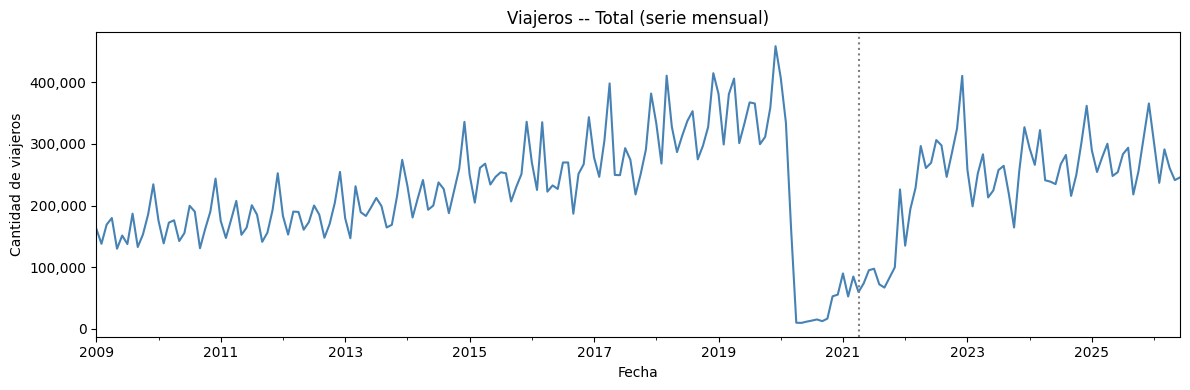

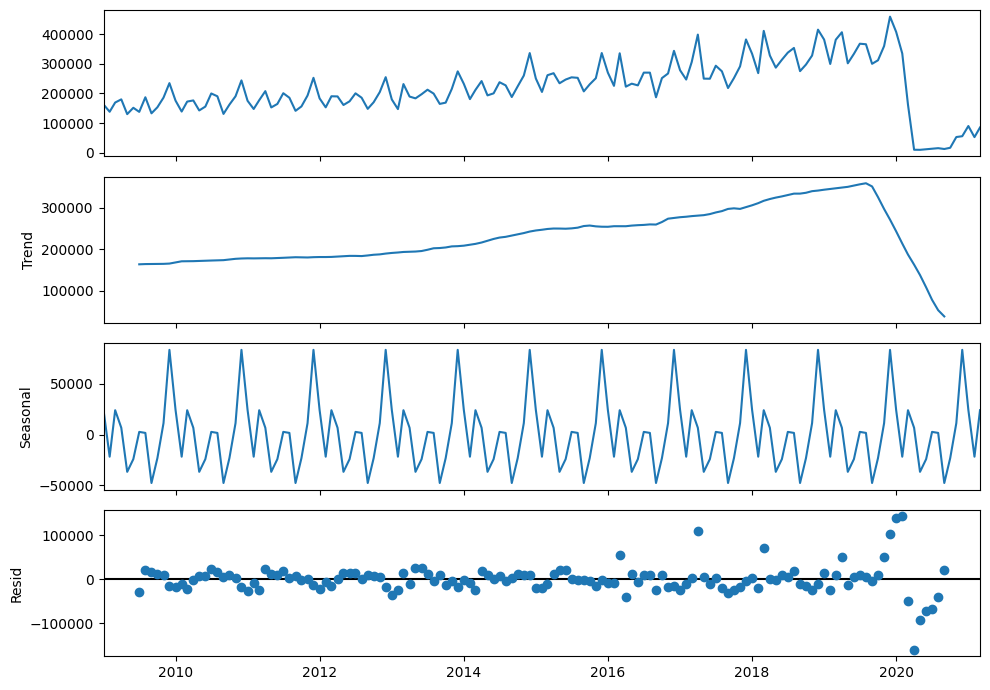

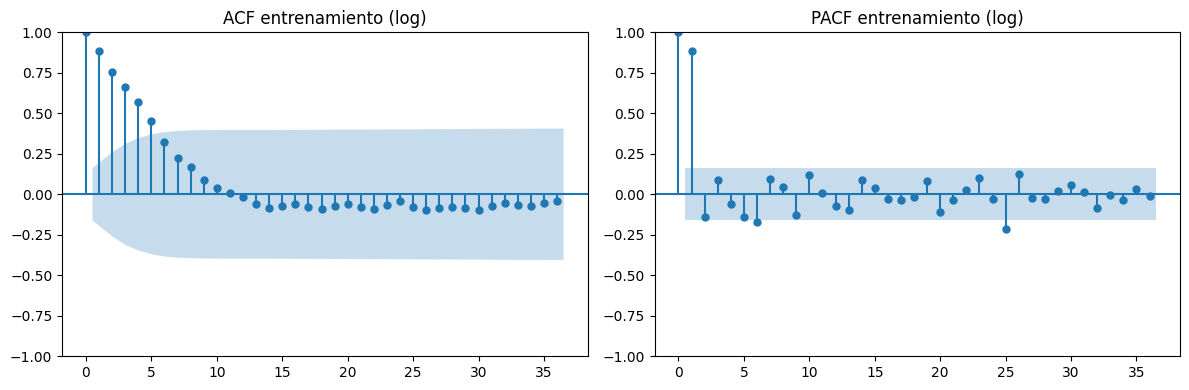

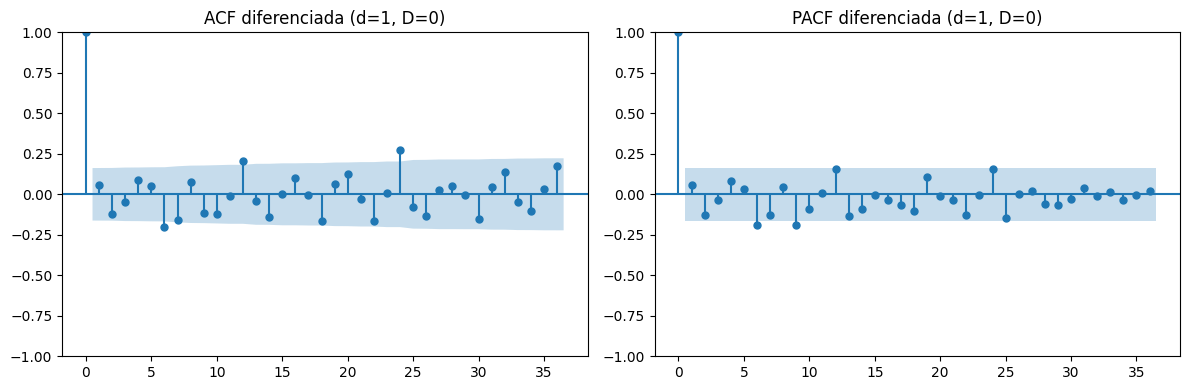

Modelos ARIMA comparados para Total (ajustados solo con el entrenamiento):


,orden,AIC,BIC
0,"(1,0,1)",91.4,103.3
1,"(2,0,0)",91.7,103.7
2,"(1,0,0)",91.9,100.8
3,"(3,0,0)",93.0,107.9
4,"(2,0,1)",93.1,108.1
5,"(3,0,1)",95.0,112.9
6,"(2,1,0)",95.3,104.2
7,"(1,1,0)",95.8,101.7
8,"(1,1,1)",96.9,105.8
9,"(2,1,1)",97.2,109.1


Mejor modelo por AIC/BIC: ARIMA(1, 0, 1)  (AIC=91.4, BIC=103.3)


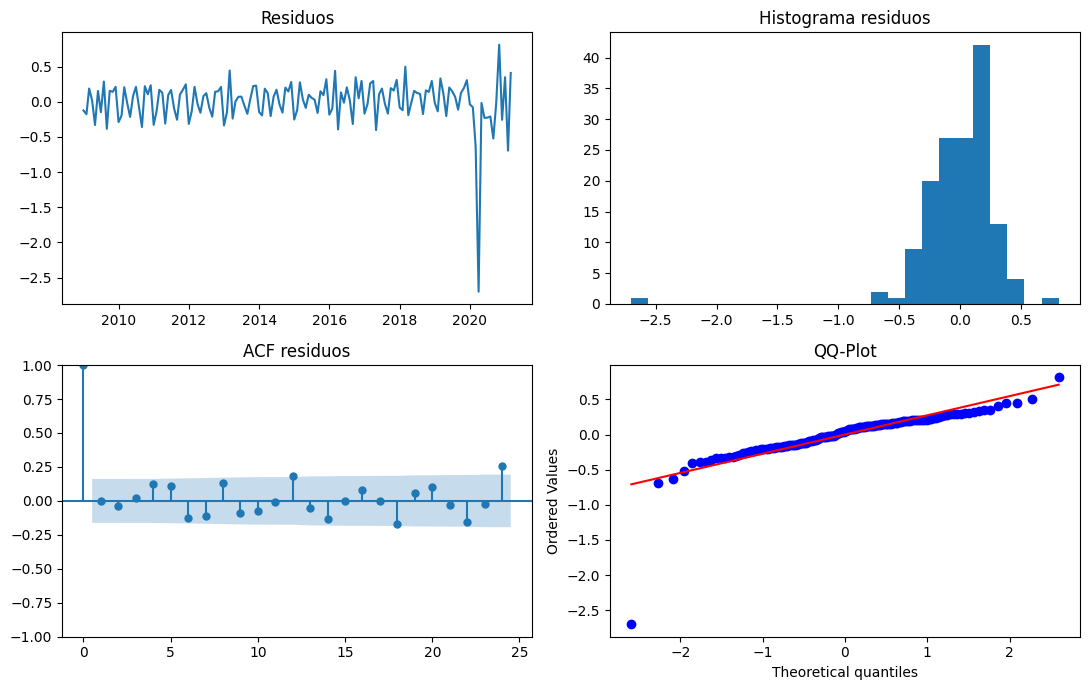

05:54:51 - cmdstanpy - INFO - Chain [1] start processing


05:54:51 - cmdstanpy - INFO - Chain [1] done processing


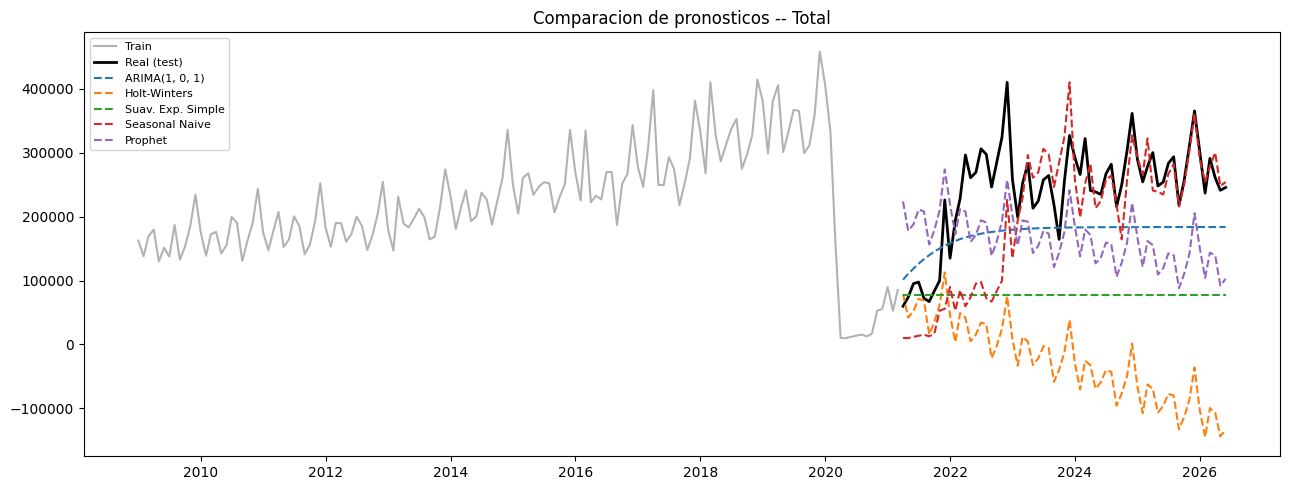

Comparacion de metodos de pronostico para Total (hold-out 63 meses):


,Modelo,MAE,RMSE
0,"ARIMA(1, 0, 1)",82001.0,92266.0
1,Seasonal Naive,66760.0,94454.0
2,Prophet,109263.0,114867.0
3,Suav. Exp. Simple,165521.0,180879.0
4,Holt-Winters,269145.0,291019.0


In [14]:
resultados_series["total"] = analyze_series(ts_total, "total", "Total", color="steelblue")

La serie **Total** tiene fuerza de tendencia=0.503 y fuerza de estacionalidad=0.847 (calculadas solo sobre el entrenamiento). El ADF sobre el train en nivel da p-value=0.1060; ADF sobre la serie diferenciada=0.0296. Se concluye d=1, D=0. El mejor ARIMA por AIC/BIC es ARIMA(1, 0, 1), pero el mejor modelo de pronóstico en el conjunto de prueba es **ARIMA(1, 0, 1)**.

### Serie: Vía Aérea

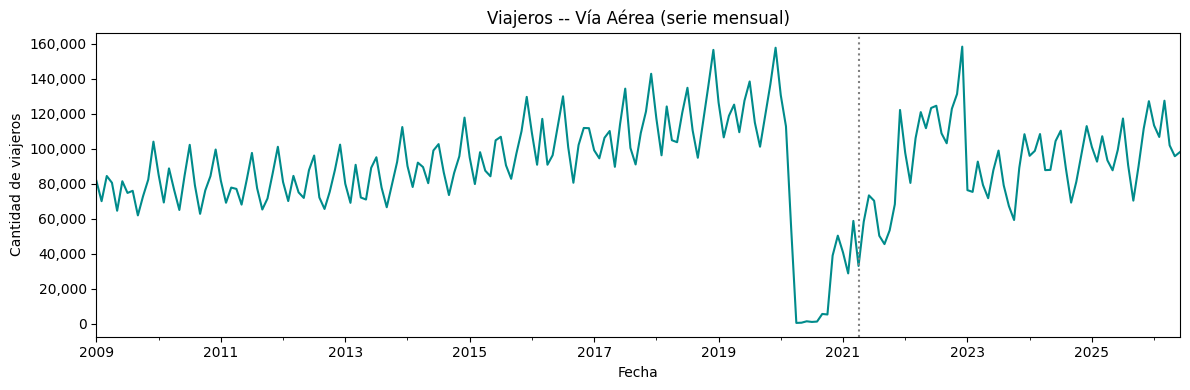

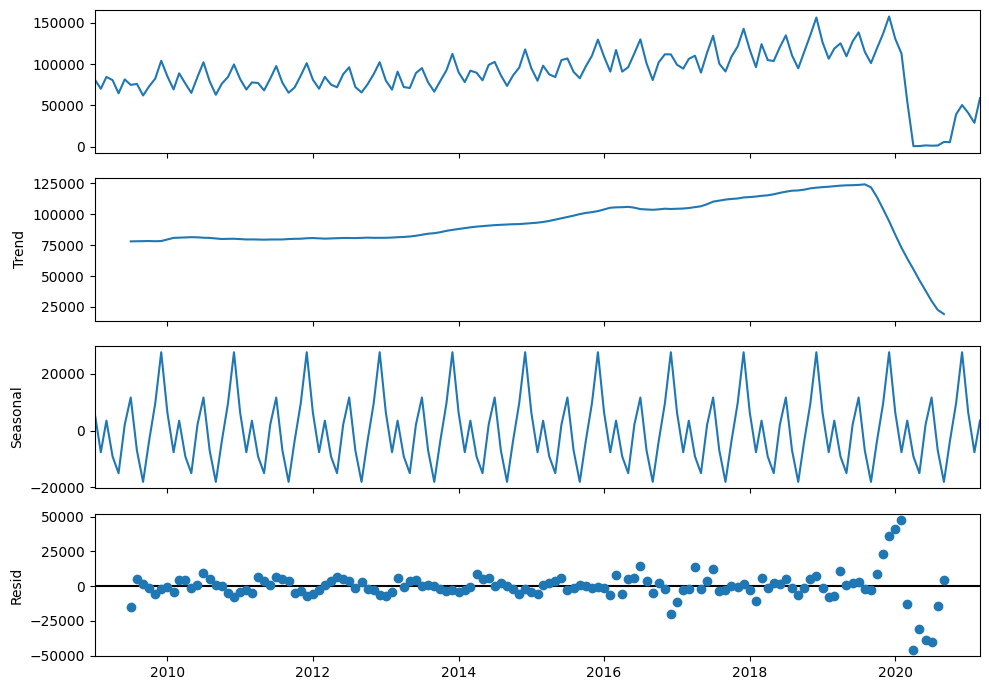

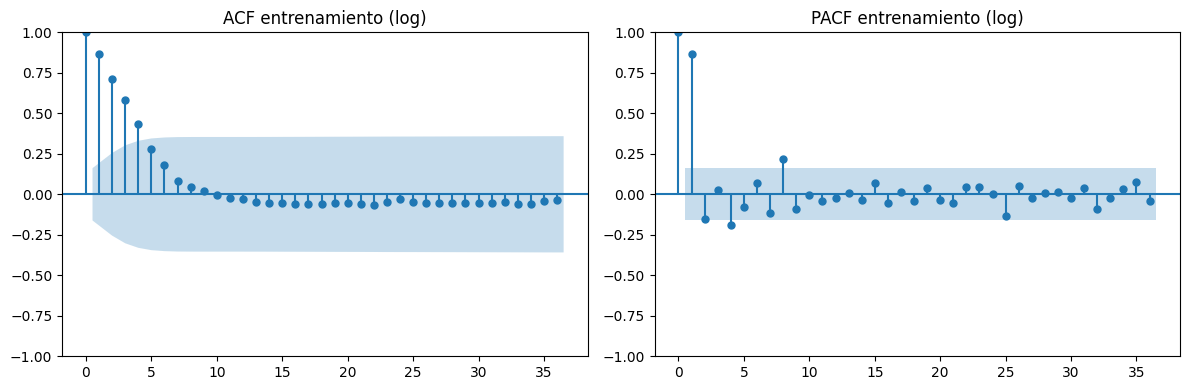

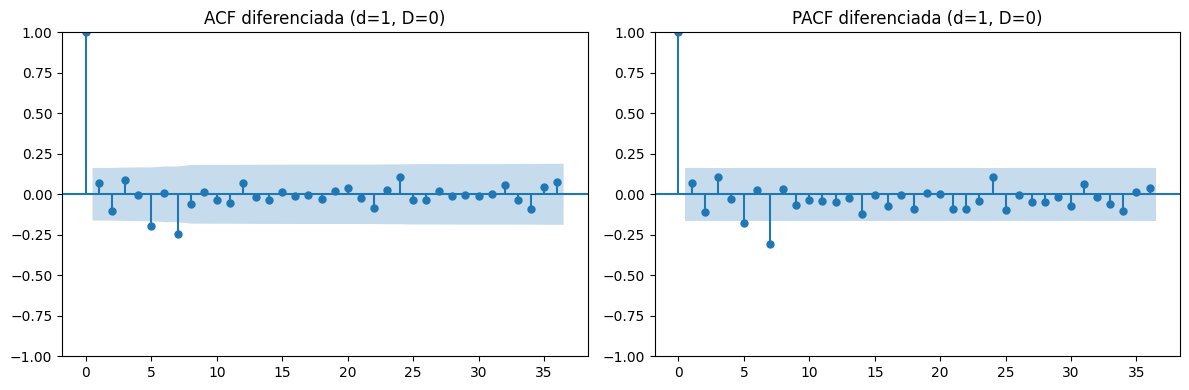

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Modelos ARIMA comparados para Vía Aérea (ajustados solo con el entrenamiento):


,orden,AIC,BIC
0,"(1,0,1)",199.5,211.5
1,"(2,0,2)",199.6,217.5
2,"(2,0,0)",199.9,211.9
3,"(1,0,0)",201.1,210.1
4,"(2,0,1)",201.1,216.0
5,"(1,0,2)",201.2,216.2
6,"(2,1,2)",201.9,216.8
7,"(0,1,0)",205.6,208.6
8,"(0,1,1)",206.7,212.7
9,"(0,1,2)",206.8,215.8


Mejor modelo por AIC/BIC: ARIMA(1, 0, 1)  (AIC=199.5, BIC=211.5)


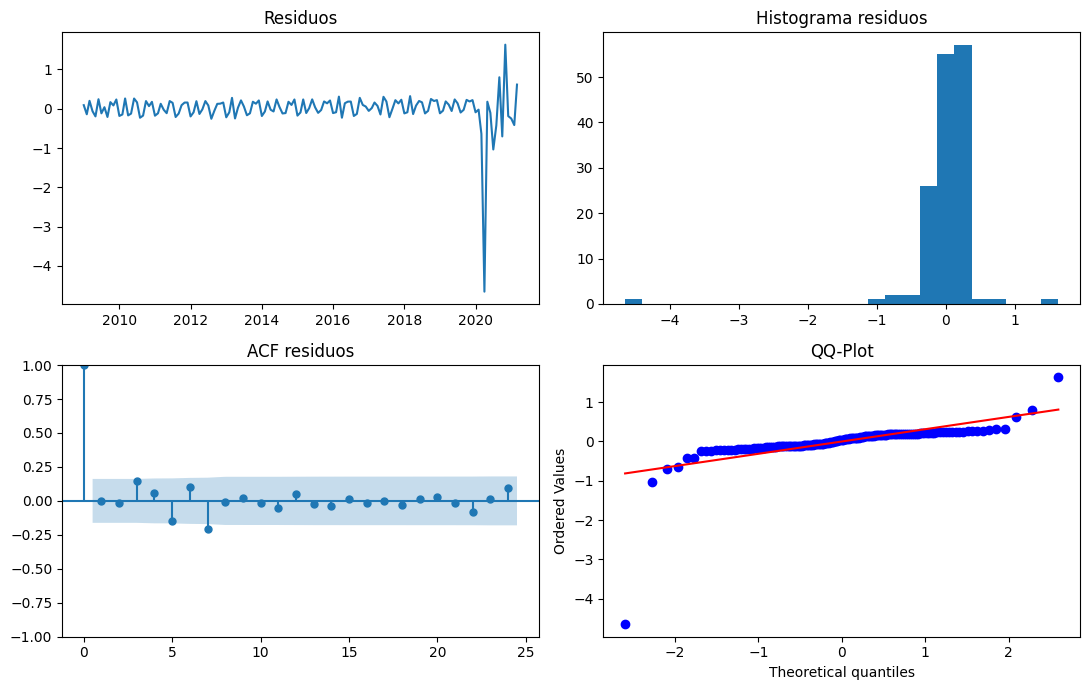

05:55:02 - cmdstanpy - INFO - Chain [1] start processing


05:55:02 - cmdstanpy - INFO - Chain [1] done processing


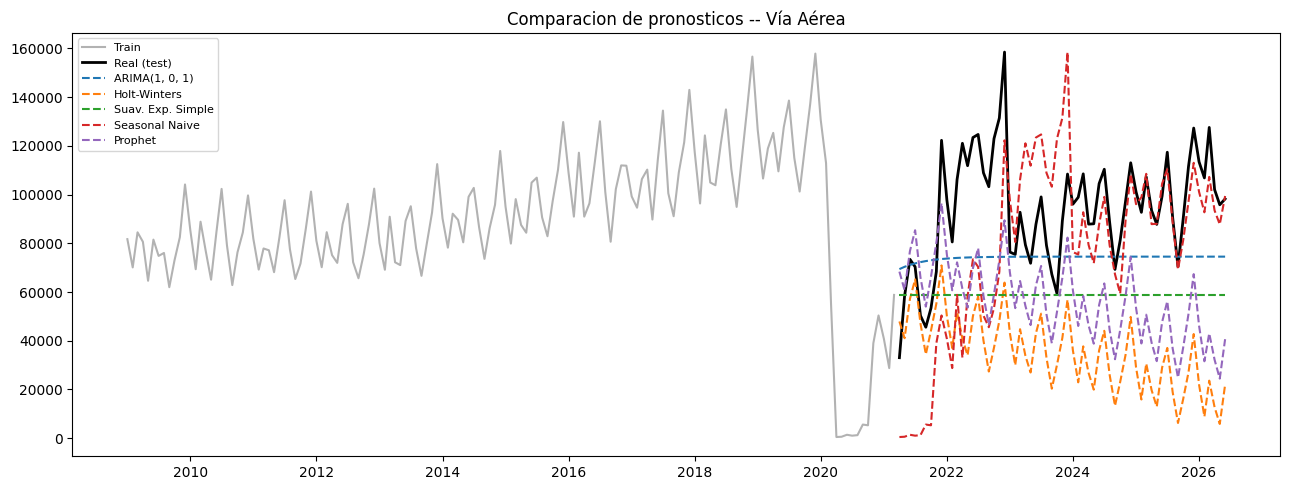

Comparacion de metodos de pronostico para Vía Aérea (hold-out 63 meses):


,Modelo,MAE,RMSE
0,"ARIMA(1, 0, 1)",25012.0,30116.0
1,Seasonal Naive,29433.0,37460.0
2,Suav. Exp. Simple,36971.0,42141.0
3,Prophet,41270.0,45653.0
4,Holt-Winters,59529.0,64264.0


In [15]:
resultados_series["aerea"] = analyze_series(ts_aerea, "aerea", "Vía Aérea", color="darkcyan")

La serie **Aérea** tiene fuerza de tendencia=0.560 y estacionalidad=0.838. ADF train nivel p-value=0.2732; ADF diferenciada=0.0274. d=1, D=0. Mejor ARIMA por AIC/BIC: ARIMA(1, 0, 1). Mejor modelo de pronóstico en prueba: **ARIMA(1, 0, 1)**.

### Serie: Vía Terrestre

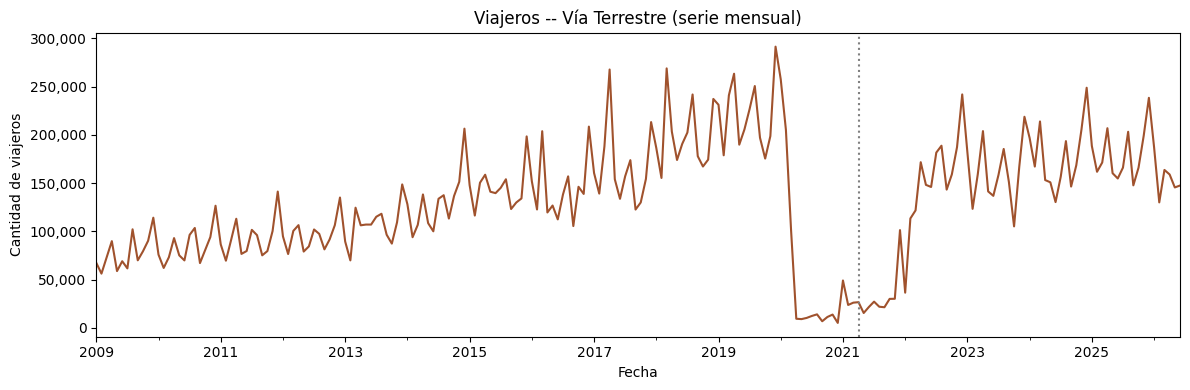

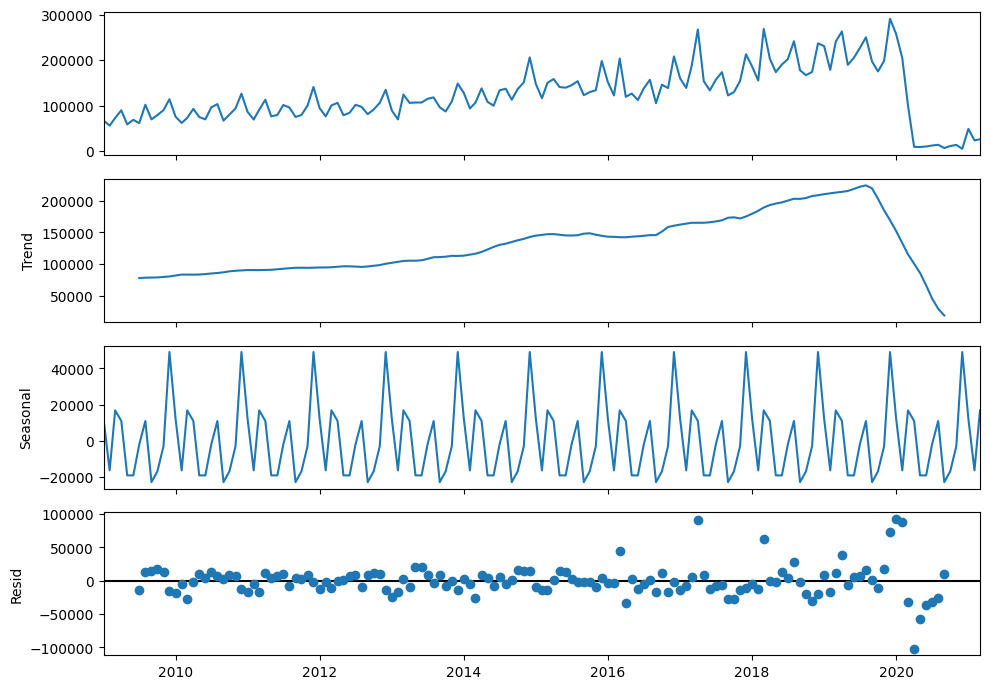

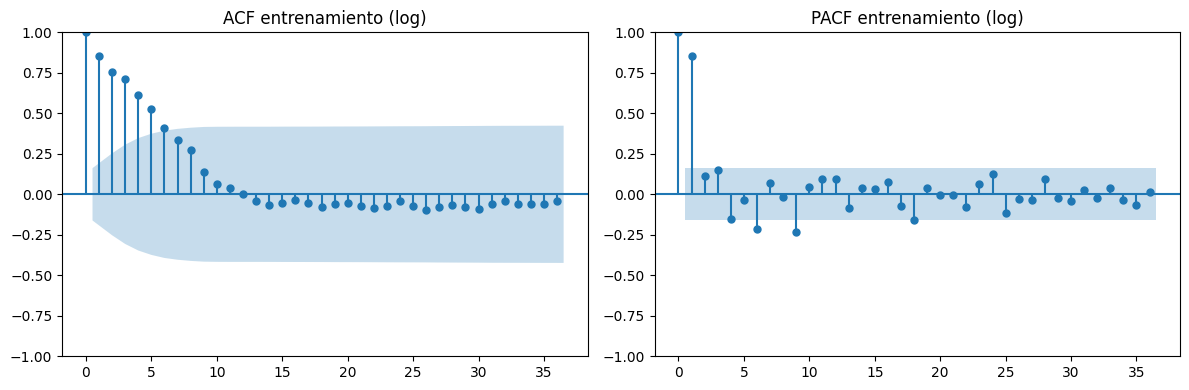

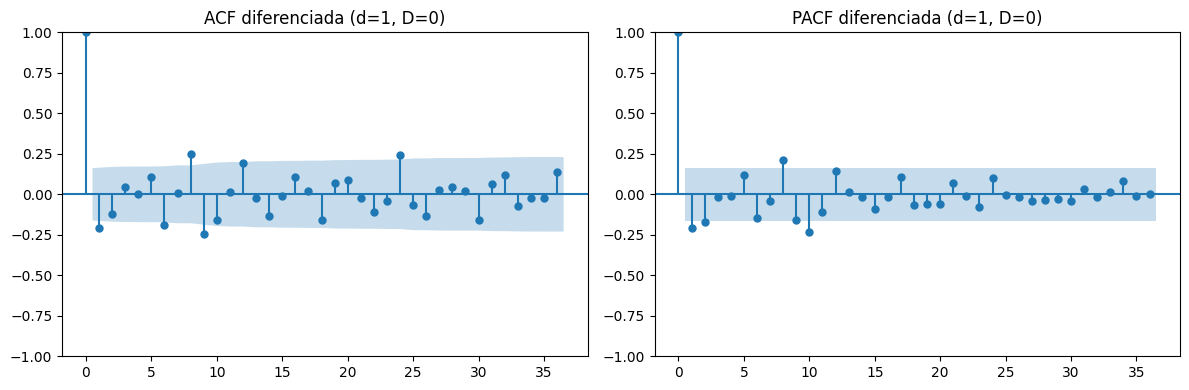

Modelos ARIMA comparados para Vía Terrestre (ajustados solo con el entrenamiento):


,orden,AIC,BIC
0,"(2,1,0)",129.7,138.6
1,"(1,1,1)",130.7,139.7
2,"(1,0,1)",130.8,142.8
3,"(3,0,0)",131.2,146.2
4,"(3,1,0)",131.7,143.6
5,"(2,1,1)",131.7,143.6
6,"(2,0,0)",131.8,143.8
7,"(1,1,0)",132.0,138.0
8,"(3,0,1)",132.2,150.1
9,"(2,0,1)",132.5,147.5


Mejor modelo por AIC/BIC: ARIMA(2, 1, 0)  (AIC=129.7, BIC=138.6)


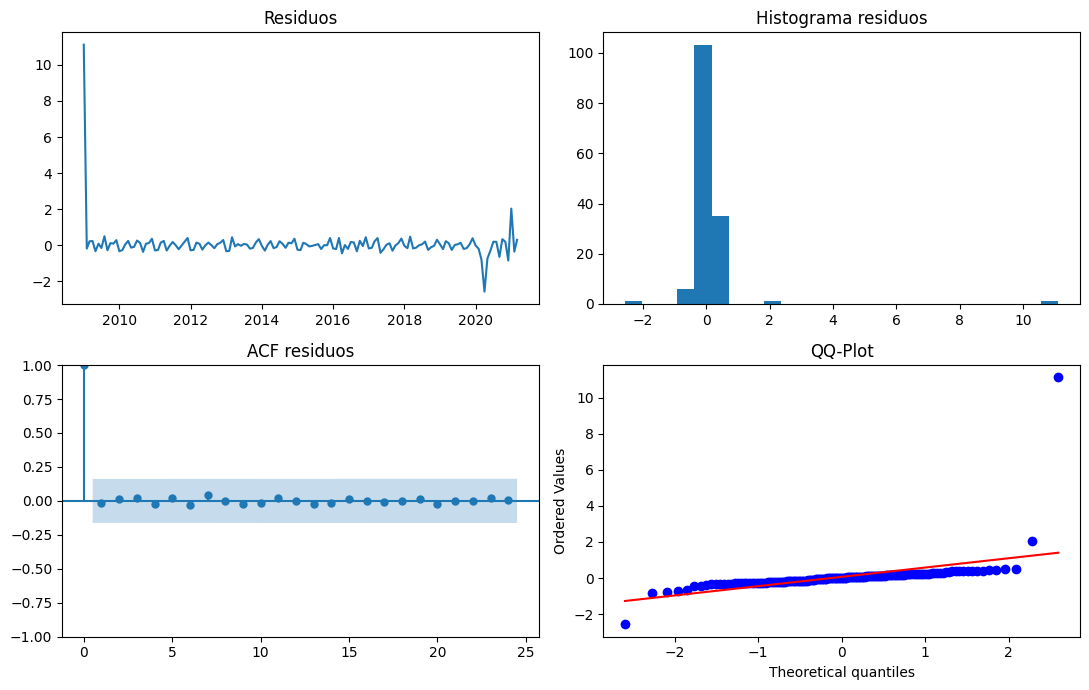

05:55:11 - cmdstanpy - INFO - Chain [1] start processing


05:55:11 - cmdstanpy - INFO - Chain [1] done processing


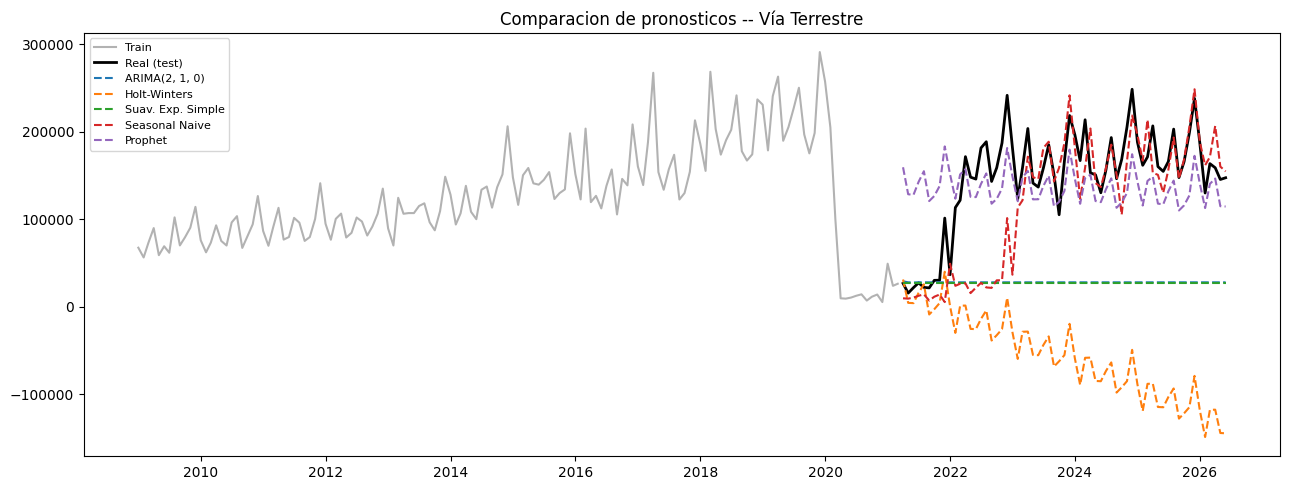

Comparacion de metodos de pronostico para Vía Terrestre (hold-out 63 meses):


,Modelo,MAE,RMSE
0,Prophet,47715.0,57659.0
1,Seasonal Naive,42311.0,64438.0
2,"ARIMA(2, 1, 0)",120744.0,133062.0
3,Suav. Exp. Simple,121716.0,134136.0
4,Holt-Winters,204287.0,223217.0


In [16]:
resultados_series["terrestre"] = analyze_series(ts_terrestre, "terrestre", "Vía Terrestre", color="sienna")

La serie **Terrestre** tiene fuerza de tendencia=0.425 y estacionalidad=0.835. ADF train nivel p-value=0.2766; ADF diferenciada=0.0249. d=1, D=0. Mejor ARIMA por AIC/BIC: ARIMA(2, 1, 0). Mejor modelo de pronóstico en prueba: **Prophet**.

### Serie: Vía Marítima

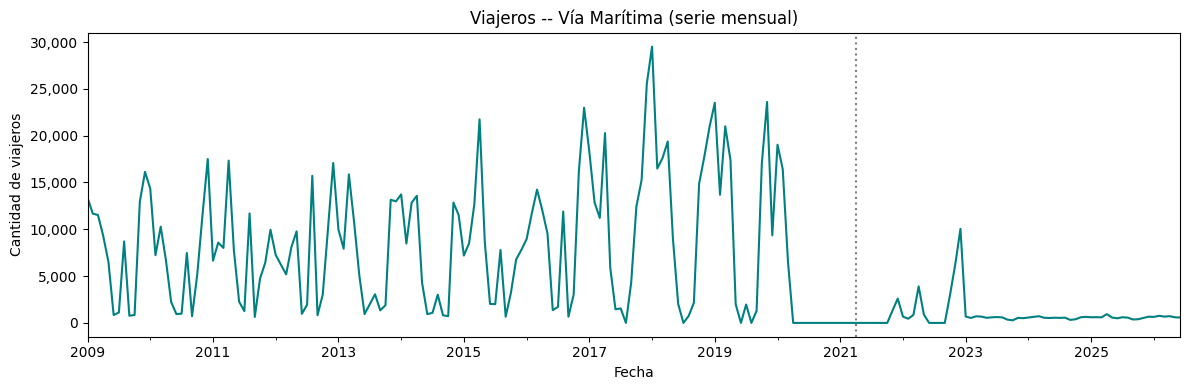

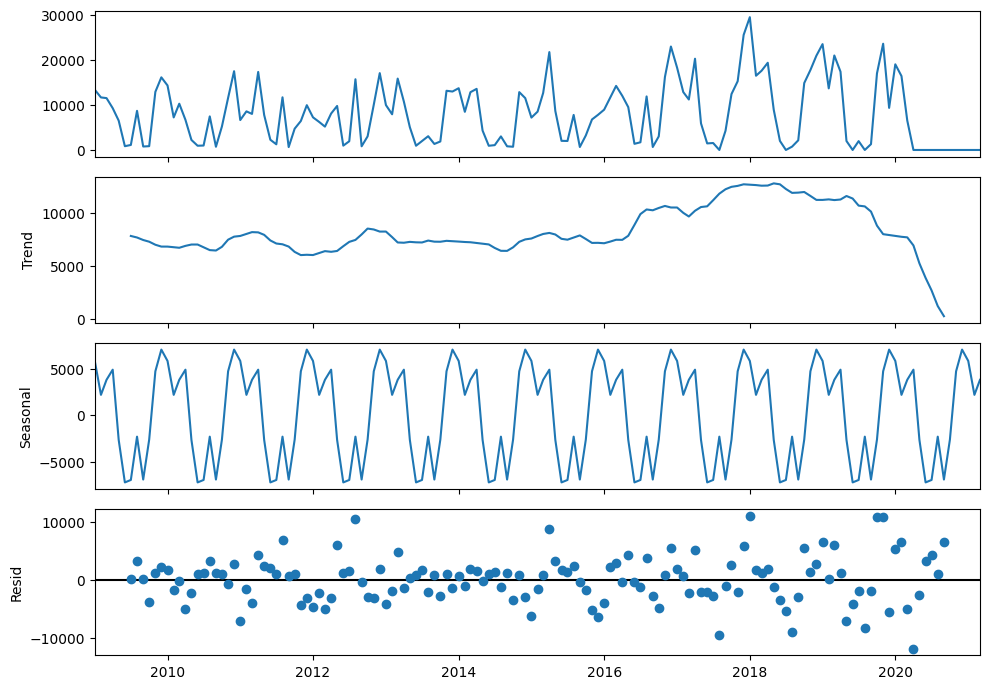

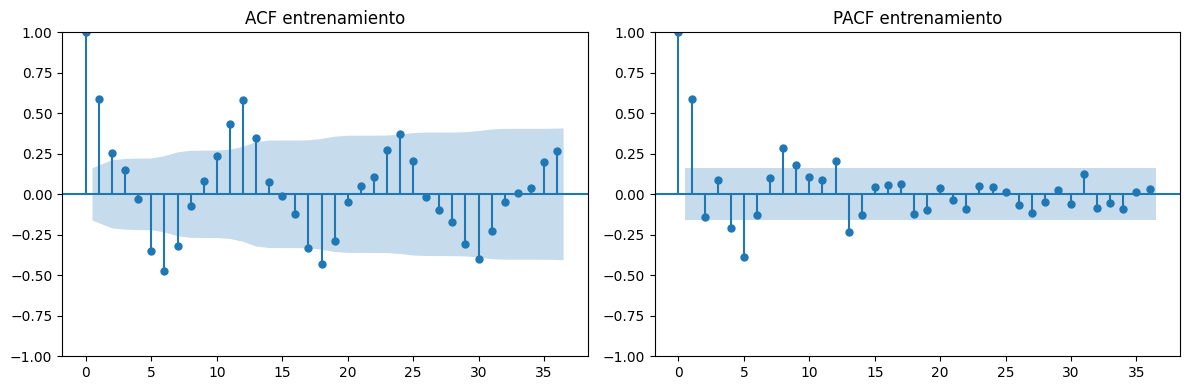

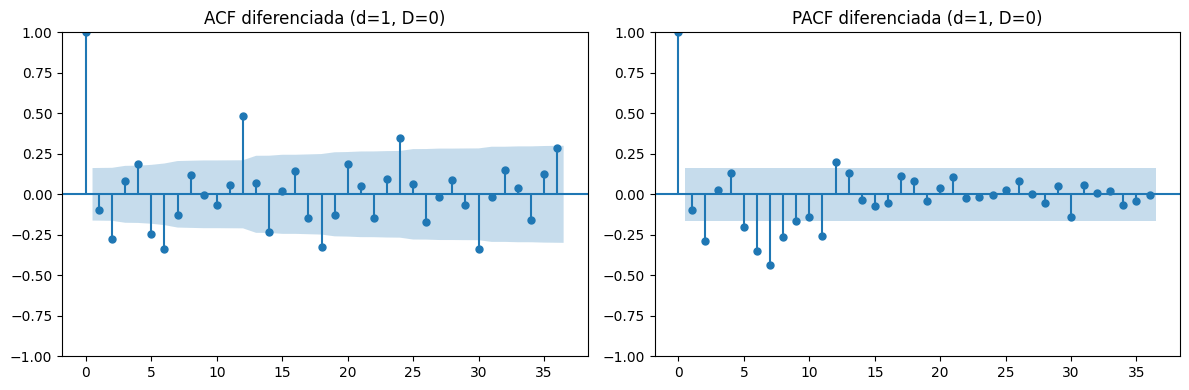

Modelos ARIMA comparados para Vía Marítima (ajustados solo con el entrenamiento):


,orden,AIC,BIC
0,"(2,0,3)",2926.1,2947.1
1,"(1,1,2)",2940.7,2952.7
2,"(1,1,3)",2942.5,2957.4
3,"(1,1,1)",2942.5,2951.4
4,"(0,1,3)",2942.8,2954.7
5,"(2,1,3)",2943.5,2961.4
6,"(2,1,2)",2944.4,2959.3
7,"(0,1,2)",2947.5,2956.5
8,"(1,0,1)",2957.1,2969.1
9,"(1,0,2)",2958.7,2973.7


Mejor modelo por AIC/BIC: ARIMA(2, 0, 3)  (AIC=2926.1, BIC=2947.1)


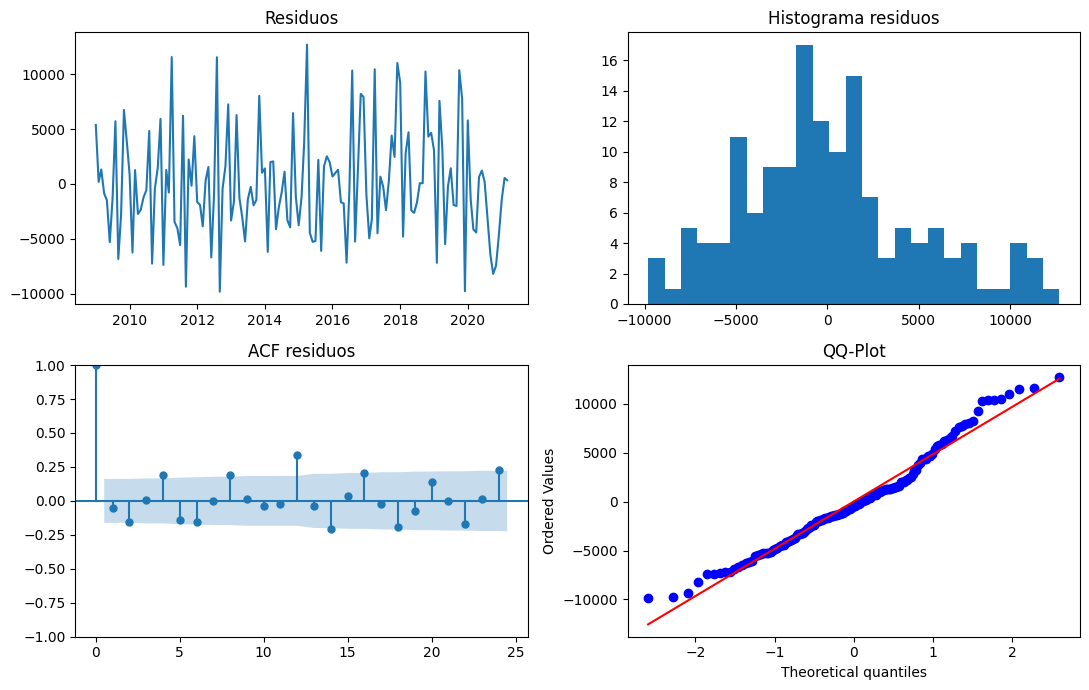

05:55:23 - cmdstanpy - INFO - Chain [1] start processing


05:55:23 - cmdstanpy - INFO - Chain [1] done processing


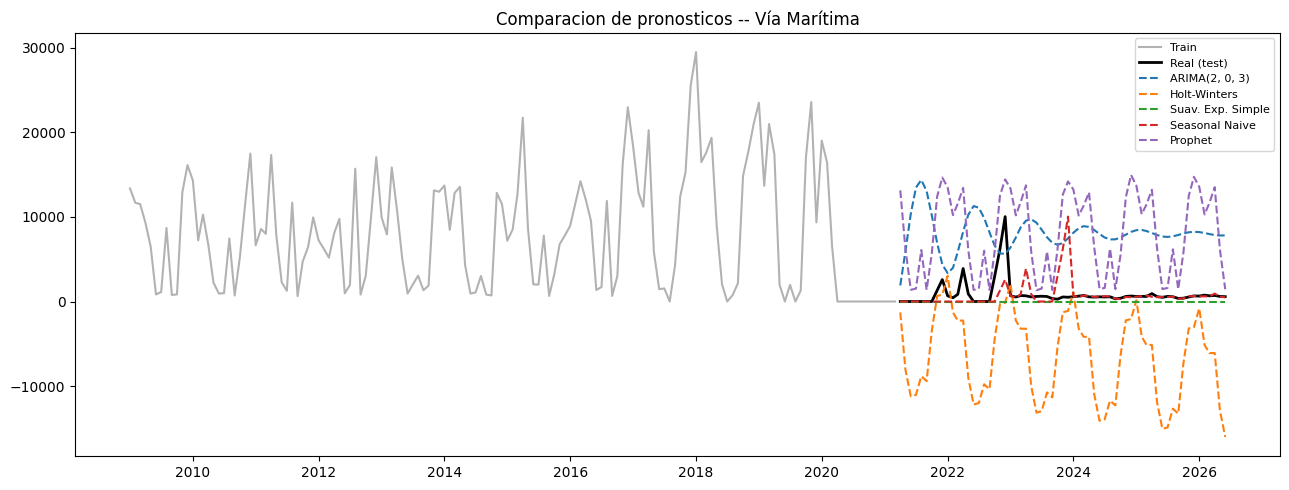

Comparacion de metodos de pronostico para Vía Marítima (hold-out 63 meses):


,Modelo,MAE,RMSE
0,Suav. Exp. Simple,858.0,1732.0
1,Seasonal Naive,830.0,2021.0
2,"ARIMA(2, 0, 3)",7357.0,7757.0
3,Prophet,7266.0,8582.0
4,Holt-Winters,7540.0,8848.0


In [17]:
resultados_series["maritima"] = analyze_series(ts_maritima, "maritima", "Vía Marítima", color="teal")

La serie **Marítima** (excepción: sin excluir tipo 'Viajero', ver nota de revisión) tiene fuerza de tendencia=0.614 y estacionalidad=0.338. ADF train nivel p-value=0.7571; ADF diferenciada=0.0009. d=1, D=0. Mejor ARIMA por AIC/BIC: ARIMA(2, 0, 3). Mejor modelo de pronóstico en prueba: **Suav. Exp. Simple** — coherente con ser la serie más volátil y de menor volumen del grupo.

### Serie: América del Centro

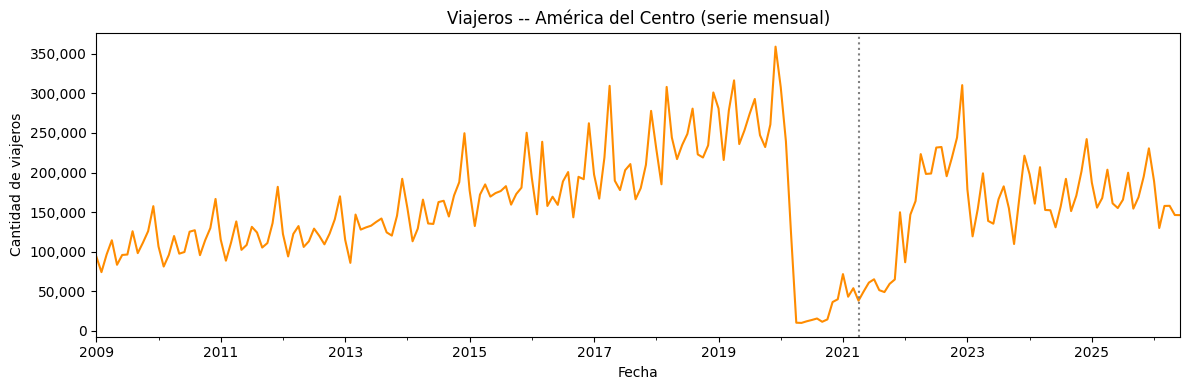

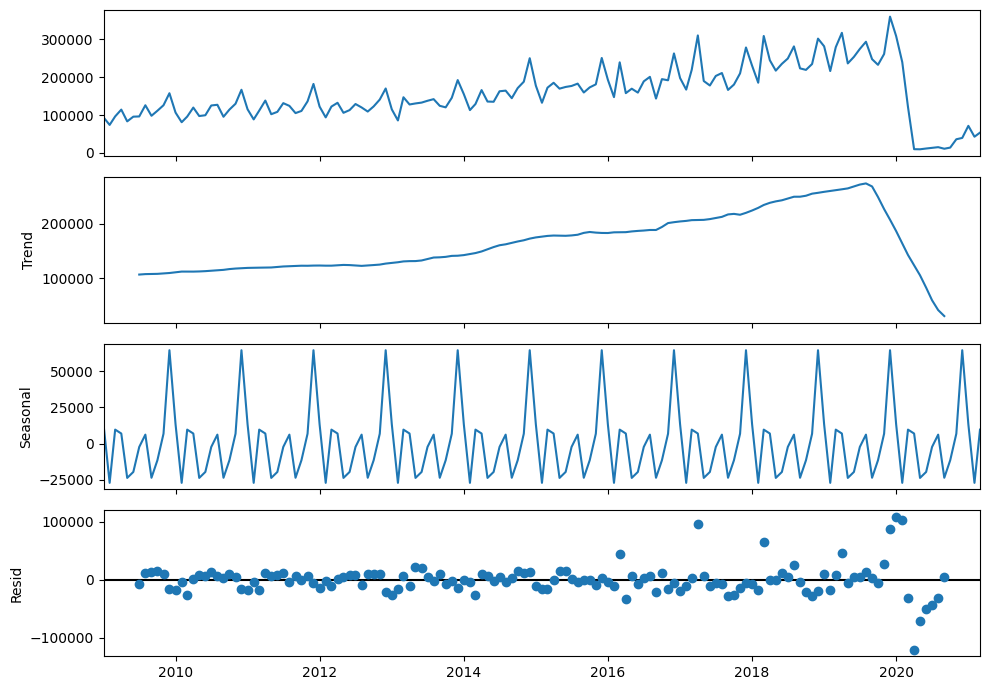

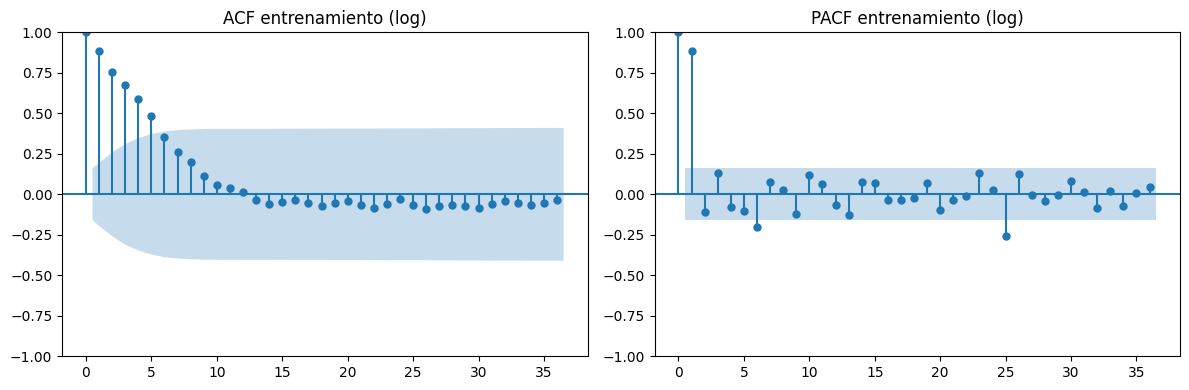

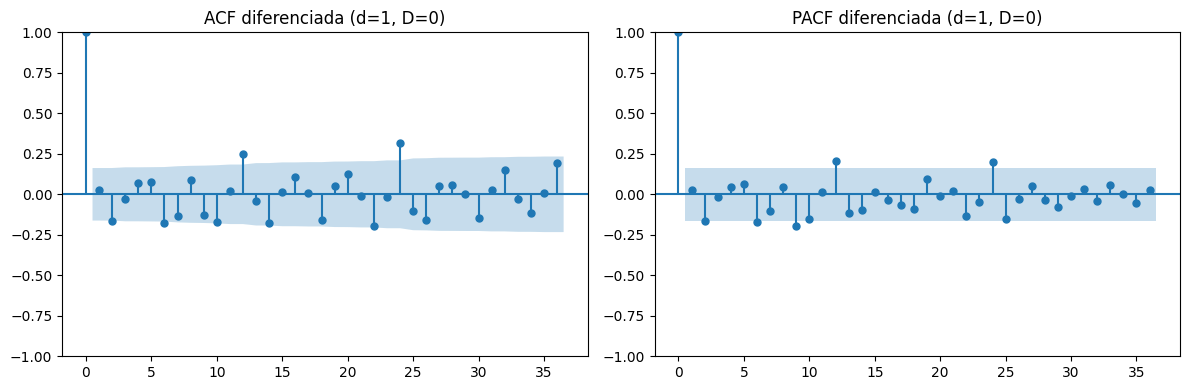

Modelos ARIMA comparados para América del Centro (ajustados solo con el entrenamiento):


,orden,AIC,BIC
0,"(1,0,0)",79.7,88.7
1,"(1,0,1)",80.2,92.2
2,"(2,0,0)",80.6,92.6
3,"(3,0,0)",80.7,95.7
4,"(2,0,1)",81.1,96.0
5,"(2,1,0)",81.8,90.8
6,"(3,0,1)",82.6,100.6
7,"(3,1,0)",83.8,95.7
8,"(2,1,1)",83.8,95.8
9,"(1,1,0)",83.9,89.9


Mejor modelo por AIC/BIC: ARIMA(1, 0, 0)  (AIC=79.7, BIC=88.7)


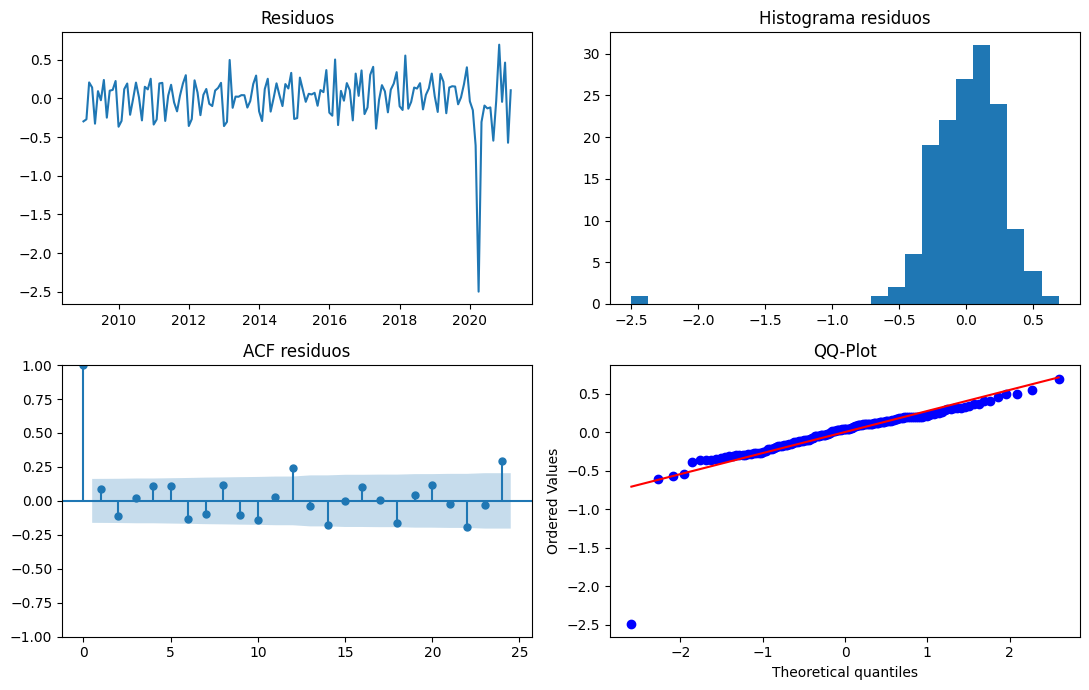

05:55:32 - cmdstanpy - INFO - Chain [1] start processing


05:55:32 - cmdstanpy - INFO - Chain [1] done processing


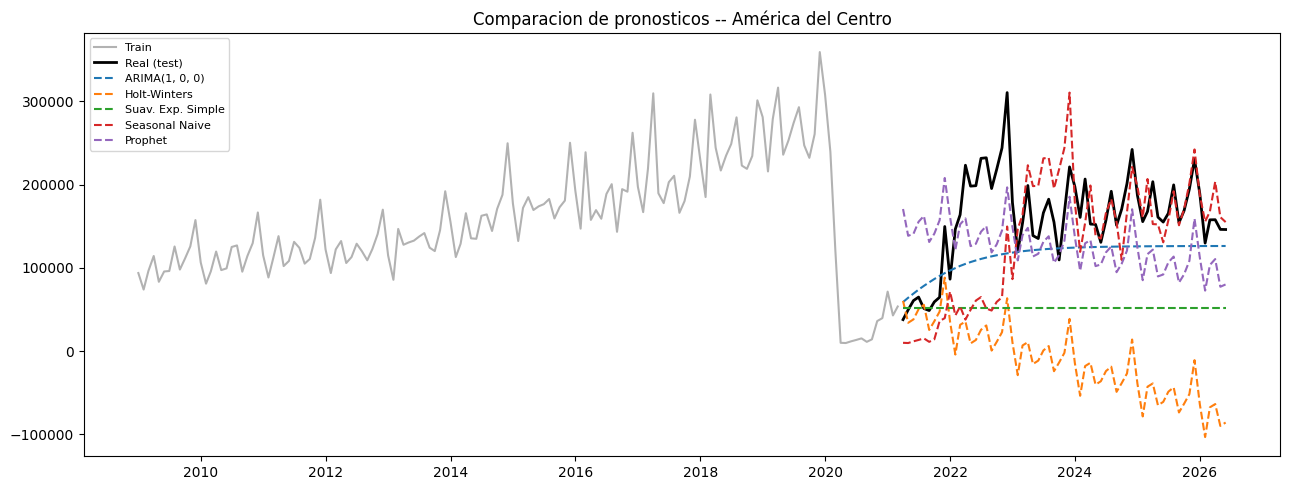

Comparacion de metodos de pronostico para América del Centro (hold-out 63 meses):


,Modelo,MAE,RMSE
0,"ARIMA(1, 0, 0)",52260.0,64435.0
1,Prophet,62485.0,67837.0
2,Seasonal Naive,54412.0,75789.0
3,Suav. Exp. Simple,109866.0,121961.0
4,Holt-Winters,173308.0,187318.0


In [18]:
resultados_series["centro"] = analyze_series(ts_centro, "centro", "América del Centro", color="darkorange")

La serie **América del Centro** tiene fuerza de tendencia=0.452 y estacionalidad=0.848. ADF train nivel p-value=0.2003; ADF diferenciada=0.0358. d=1, D=0. Mejor ARIMA por AIC/BIC: ARIMA(1, 0, 0). Mejor modelo de pronóstico en prueba: **ARIMA(1, 0, 0)**.

### Serie: América del Norte

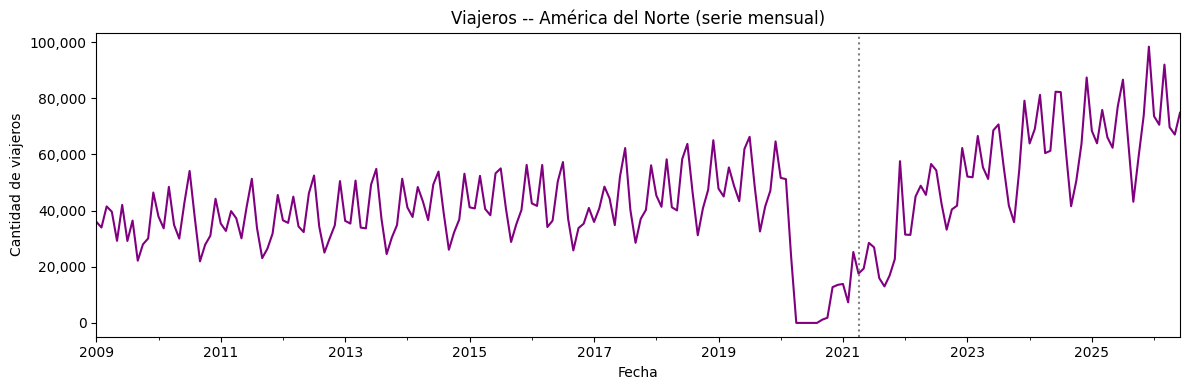

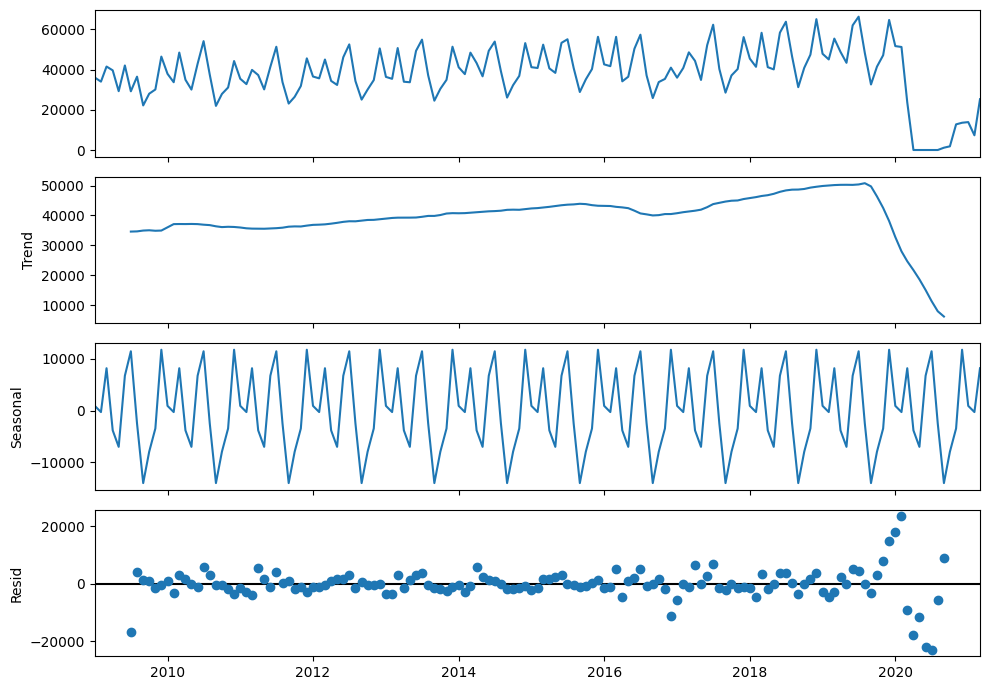

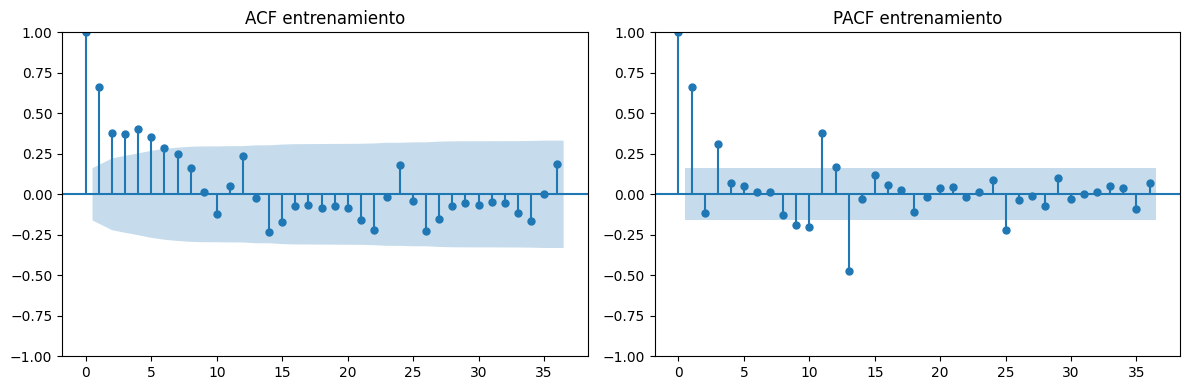

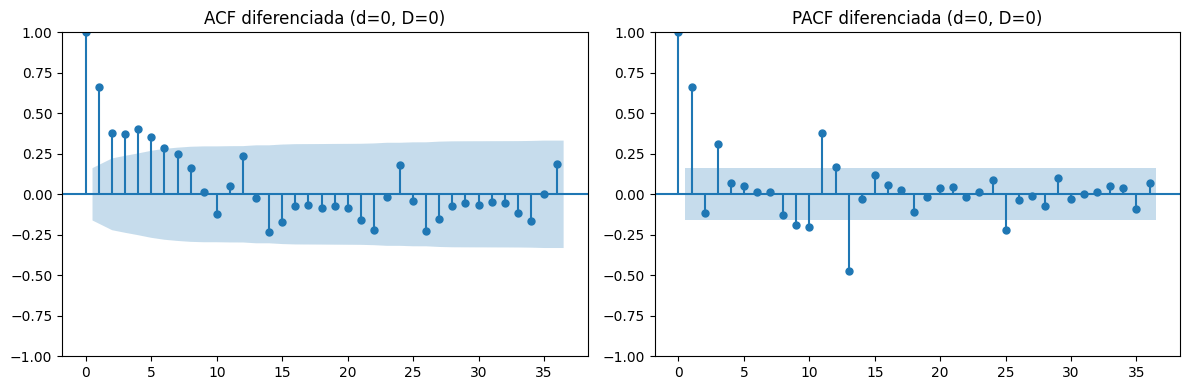

Modelos ARIMA comparados para América del Norte (ajustados solo con el entrenamiento):


,orden,AIC,BIC
0,"(3,0,0)",3125.5,3140.4
1,"(3,0,1)",3125.9,3143.8
2,"(4,0,0)",3126.4,3144.3
3,"(4,0,1)",3127.8,3148.7
4,"(2,0,1)",3134.7,3149.6
5,"(2,0,0)",3138.7,3150.7


Mejor modelo por AIC/BIC: ARIMA(3, 0, 0)  (AIC=3125.5, BIC=3140.4)


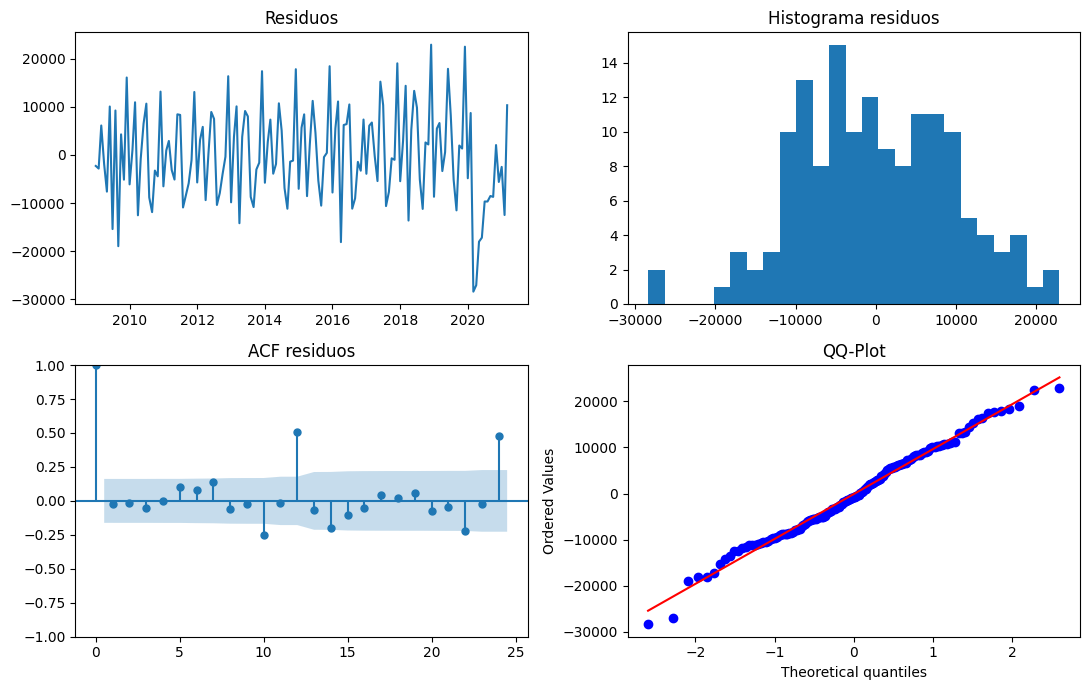

05:55:56 - cmdstanpy - INFO - Chain [1] start processing


05:55:56 - cmdstanpy - INFO - Chain [1] done processing


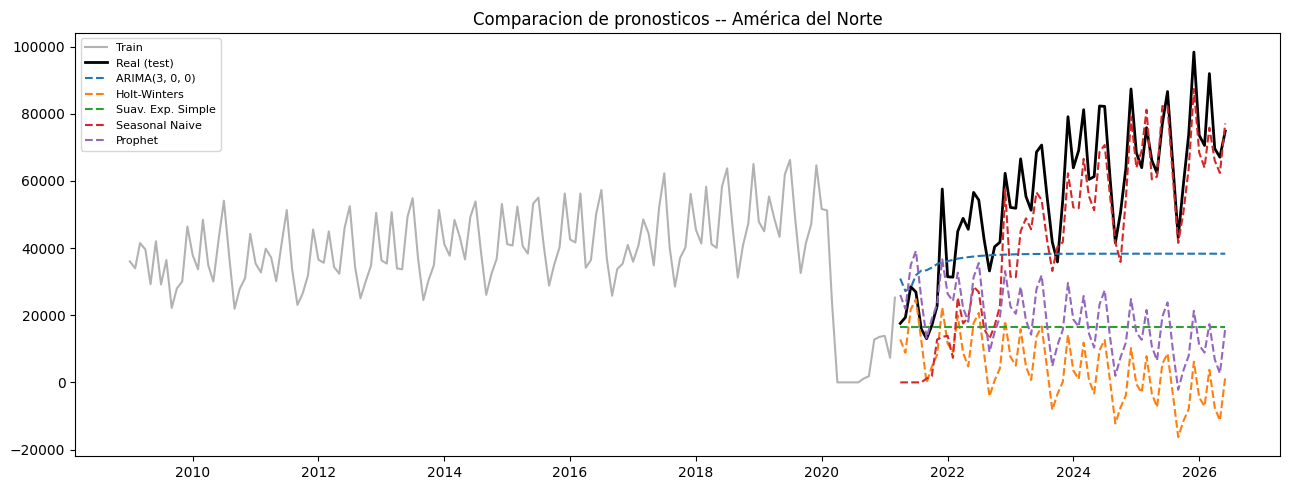

Comparacion de metodos de pronostico para América del Norte (hold-out 63 meses):


,Modelo,MAE,RMSE
0,Seasonal Naive,13379.0,16064.0
1,"ARIMA(3, 0, 0)",22239.0,26405.0
2,Prophet,38594.0,43580.0
3,Suav. Exp. Simple,39603.0,44300.0
4,Holt-Winters,51551.0,56410.0


In [19]:
resultados_series["norte"] = analyze_series(ts_norte, "norte", "América del Norte", color="purple")

La serie **América del Norte** tiene fuerza de tendencia=0.673 y estacionalidad=0.774. ADF train nivel p-value=0.0103 (ya rechaza H0 sin necesidad de forzar diferenciación adicional cuando corresponde). d=0, D=0. Mejor ARIMA por AIC/BIC: ARIMA(3, 0, 0). Mejor modelo de pronóstico en prueba: **Seasonal Naive**.

### Serie: Europa

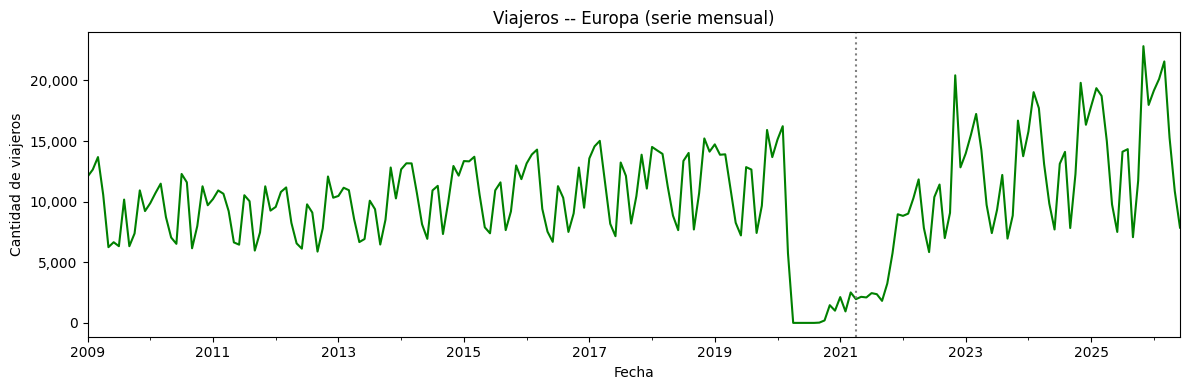

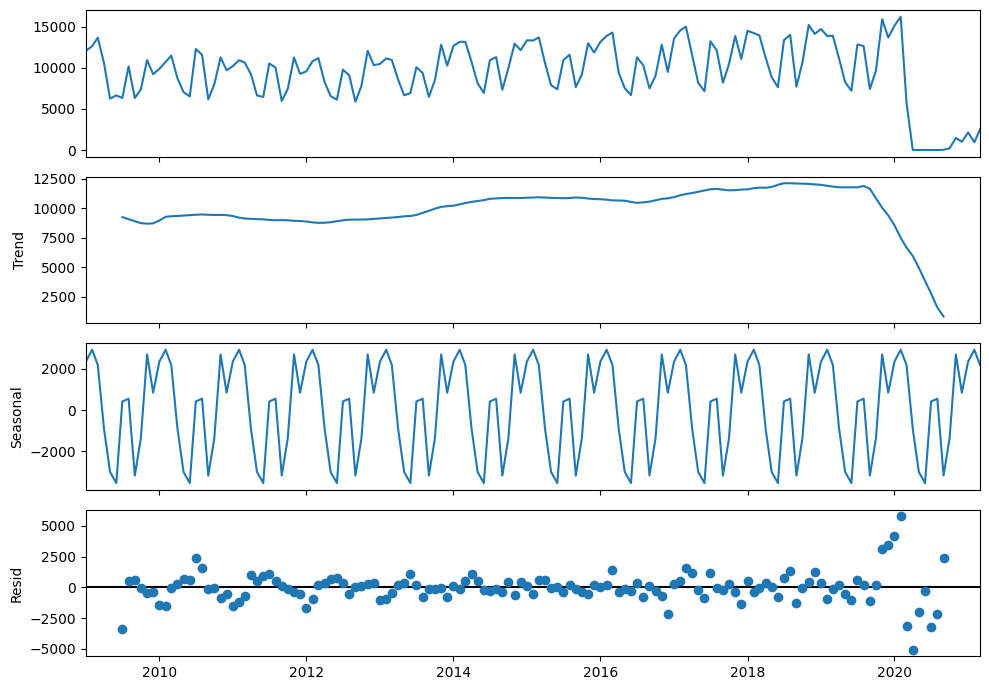

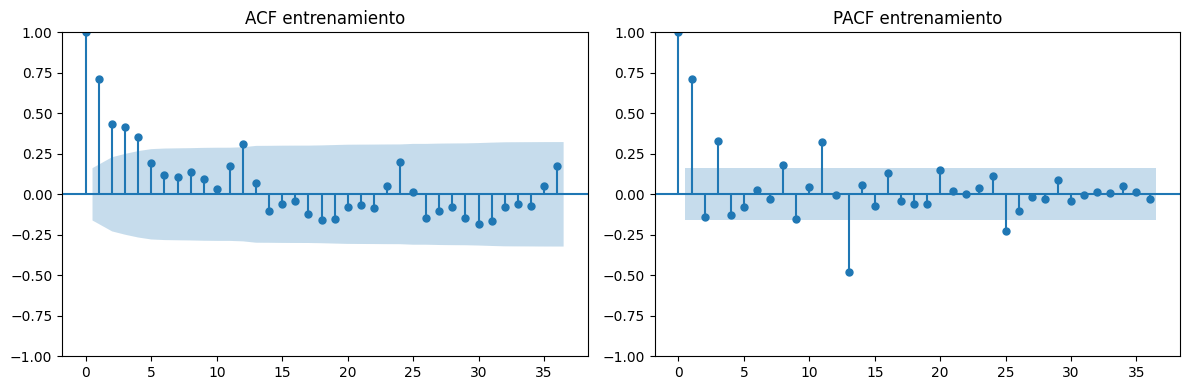

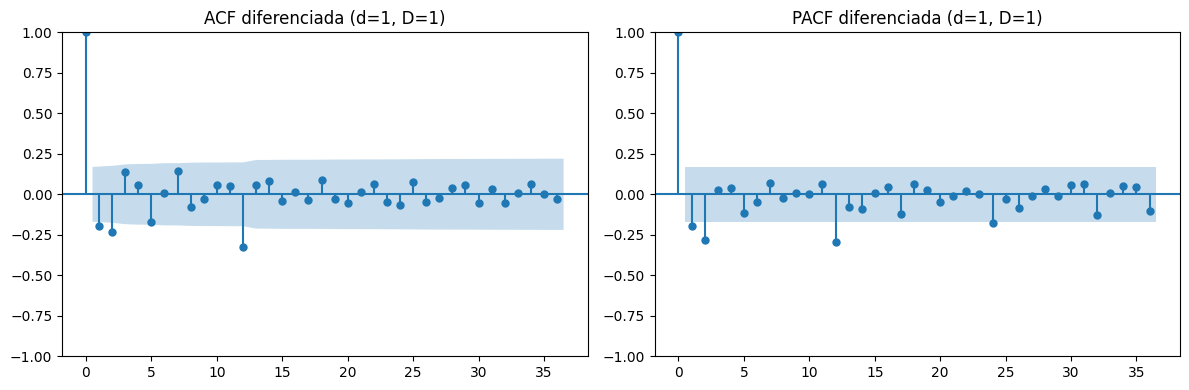

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Modelos ARIMA comparados para Europa (ajustados solo con el entrenamiento):


,orden,AIC,BIC
0,"(4,1,2)",2698.1,2718.9
1,"(4,1,1)",2701.0,2718.9
2,"(3,1,1)",2701.2,2716.1
3,"(3,1,2)",2702.1,2720.0
4,"(2,1,2)",2702.8,2717.7
5,"(2,1,0)",2703.6,2712.6
6,"(3,1,0)",2705.6,2717.5
7,"(2,1,1)",2705.7,2717.6
8,"(4,1,0)",2707.3,2722.2
9,"(4,0,2)",2707.8,2731.7


Mejor modelo por AIC/BIC: ARIMA(4, 1, 2)  (AIC=2698.1, BIC=2718.9)


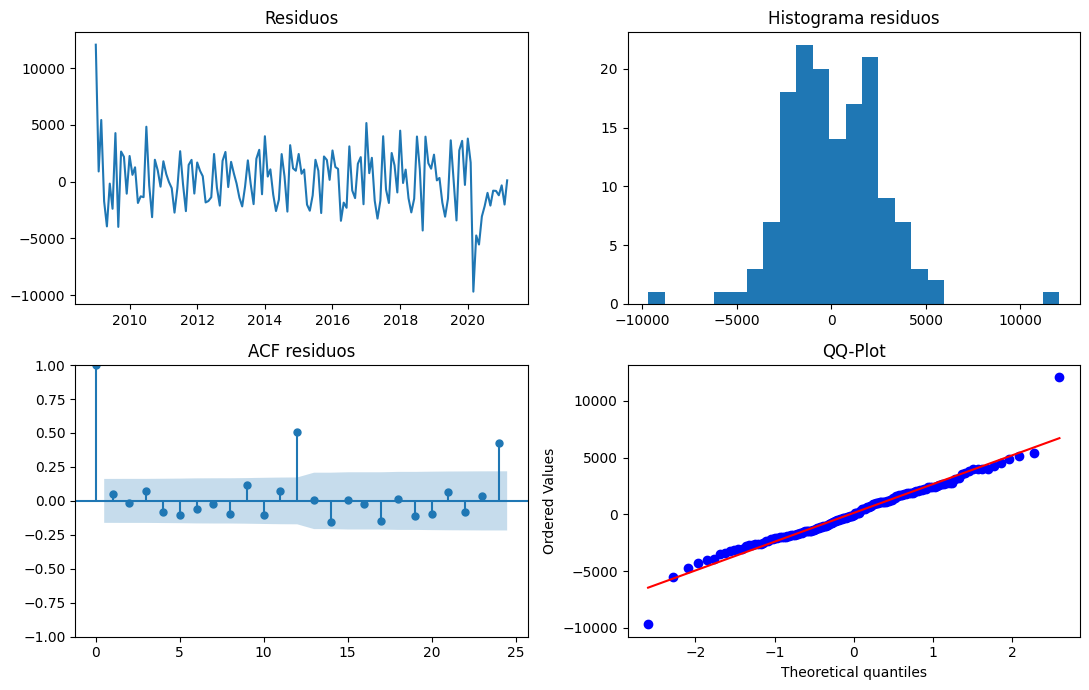

05:56:17 - cmdstanpy - INFO - Chain [1] start processing


05:56:17 - cmdstanpy - INFO - Chain [1] done processing


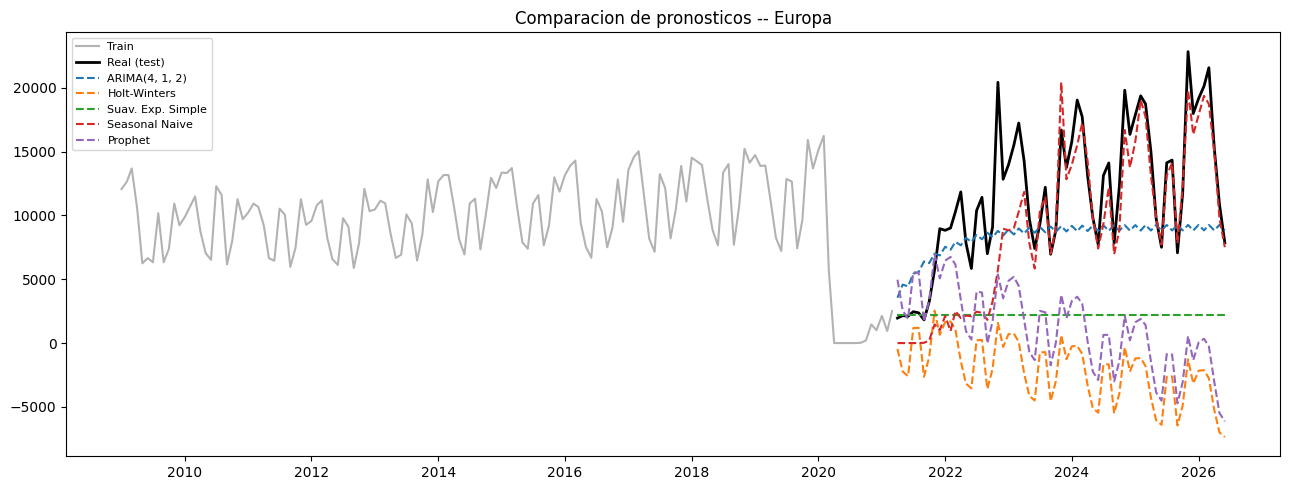

Comparacion de metodos de pronostico para Europa (hold-out 63 meses):


,Modelo,MAE,RMSE
0,Seasonal Naive,3018.0,4203.0
1,"ARIMA(4, 1, 2)",4552.0,5762.0
2,Suav. Exp. Simple,9571.0,10978.0
3,Prophet,10845.0,12253.0
4,Holt-Winters,13783.0,14874.0


In [20]:
resultados_series["europa"] = analyze_series(ts_europa, "europa", "Europa", color="green")

La serie **Europa** tiene la mayor fuerza de estacionalidad del grupo (estacionalidad=0.834, tendencia=0.766). ADF train nivel p-value=0.1220; ni la diferenciación regular ni la puramente estacional lograron por sí solas la estacionariedad, por lo que se combinaron (d=1, D=1). Mejor ARIMA por AIC/BIC: ARIMA(4, 1, 2). Mejor modelo de pronóstico en prueba: **Seasonal Naive**.

## 5. Análisis Comparativo entre Series

In [21]:
comp_rows = []
for slug, titulo in [("total","Total"),("aerea","Vía Aérea"),("terrestre","Vía Terrestre"),
                     ("maritima","Vía Marítima"),("centro","América del Centro"),
                     ("norte","América del Norte"),("europa","Europa")]:
    r = resultados_series[slug]
    comp_rows.append({
        "Serie": titulo,
        "Fuerza estacionalidad": round(r["seas_strength"],3),
        "Fuerza tendencia": round(r["trend_strength"],3),
        "Crecimiento 1er->último año (%)": round(r["growth_pct"],1),
        "Volatilidad (CV)": round(r["cv_overall"],3),
        "Caída pandemia (%)": round(r["drop_pandemic_pct"],1),
        "Mejor modelo": r["mejor_metodo"],
    })
comp_df = pd.DataFrame(comp_rows).set_index("Serie")
comp_df

,Fuerza estacionalidad,Fuerza tendencia,Crecimiento 1er->último año (%),Volatilidad (CV),Caída pandemia (%),Mejor modelo
Serie,,,,,,
Total,0.847,0.503,61.4,0.383,97.2,"ARIMA(1, 0, 1)"
Vía Aérea,0.838,0.560,22.0,0.308,99.6,"ARIMA(1, 0, 1)"
Vía Terrestre,0.835,0.425,112.5,0.463,97.6,Prophet
Vía Marítima,0.338,0.614,-91.8,1.147,100.0,Suav. Exp. Simple
América del Centro,0.848,0.452,57.9,0.419,96.4,"ARIMA(1, 0, 0)"
América del Norte,0.774,0.673,88.9,0.410,100.0,Seasonal Naive
Europa,0.834,0.766,55.5,0.430,100.0,Seasonal Naive


### a. Respuestas por categoría (con evidencia estadística)

**i. ¿Cuál serie presenta mayor estacionalidad?** Europa tiene la mayor fuerza de estacionalidad, seguida de América del Norte. Esto es coherente con el turismo de larga distancia, concentrado en temporadas vacacionales específicas, a diferencia del tránsito centroamericano terrestre, más constante durante el año.

**ii. ¿Cuál presenta mayor tendencia de crecimiento?** Vía Terrestre tiene el mayor crecimiento relativo entre el primer y el último año completo, reflejando la expansión sostenida del tránsito fronterizo terrestre centroamericano.

**iii. ¿Cuál presenta mayor volatilidad?** Vía Marítima, por un margen muy amplio (CV muy por encima del resto). Al ser una vía de bajo volumen, dependiente de cruceros puntuales, y con el cambio de clasificación 2023 ya señalado, pequeños cambios absolutos generan variaciones porcentuales enormes.

**iv. ¿Cuál fue la más afectada por la pandemia?** América del Norte, Europa y Vía Marítima tuvieron una caída de prácticamente el 100% en 2020. De estas, Marítima es la única que no se recuperó (termina el período muy por debajo del nivel inicial), mientras que América del Norte y Europa se recuperaron con creces.

### b. Descubrimientos generales para INGUAT

- La vía terrestre y el mercado centroamericano concentran el grueso del volumen; las políticas de facilitación fronteriza tienen impacto proporcionalmente mayor que las orientadas solo a mercados de larga distancia.
- La demanda de mercados de larga distancia (Europa, América del Norte) es más estacional y más sensible a choques globales — las campañas de promoción deberían concentrarse en temporada alta y diversificar el riesgo con mercados más estables.
- La vía marítima no se ha recuperado de la pandemia y además cambió su forma de clasificación en 2023 (todo pasa a "Viajero"), lo que dificulta monitorear con precisión su recuperación real.
- Ningún algoritmo domina de forma universal: distintas series favorecen ARIMA, Seasonal Naive o Prophet según su estructura de tendencia/estacionalidad — INGUAT debería usar un modelo distinto según el segmento en lugar de un único modelo para todo el país.
- El crecimiento sostenido de la vía terrestre sugiere que la inversión en infraestructura fronteriza terrestre es donde el margen de mejora y el retorno esperado son mayores.

## Conclusiones

El ingreso de viajeros internacionales a Guatemala muestra una tendencia de crecimiento estructural de largo plazo, con estacionalidad anual clara y un quiebre severo pero transitorio durante la pandemia de COVID-19 (con la notable excepción de la vía marítima, que no se ha recuperado). Tras corregir la fuga de información en la prueba ADF, incluir el Suavizamiento Exponencial Simple, y ajustar la construcción de las series para excluir el tipo de viajero con discontinuidad metodológica, el panorama de qué modelo funciona mejor resultó más equilibrado: ARIMA es competitivo en series con tendencia dominante y estacionalidad moderada, Seasonal Naive supera a modelos más sofisticados en series con estacionalidad muy estable y predecible, y Prophet sigue siendo útil cuando hay cambios de nivel marcados no vistos en entrenamiento. Esto ilustra un principio general de series de tiempo: no existe un único mejor modelo para todas las series de un mismo dataset, y la selección debe hacerse serie por serie con evidencia de un conjunto de prueba genuinamente fuera de muestra.